In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['pdf.fonttype'] = 42

/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/

In [2]:
h21 = sc.read_h5ad("/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Yuanyuan/BG_cellbender/bg_astro/HMBA_human_Astro_21clusters_withCellBenderLayerUMAP_aibs_epoch50.h5ad")
h21

AnnData object with n_obs × n_vars = 136684 × 36601
    obs: 'Neighborhood', 'Class', 'Subclass', 'Group', 'Cluster', 'cluster_id', 'cell_type_ontology_term', 'load_id', 'donor_id', 'assay', 'assay_ontology_term_id', 'organism', 'organism_ontology_term_id', 'development_stage', 'anatomical_region', 'anatomical_region_merged', 'anatomical_region_ontology_term_id', 'brain_region_ontology_term_id', 'self_reported_sex', 'self_reported_sex_ontology_term_id', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'disease', 'disease_ontology_term_id', 'suspension_type', 'is_primary_data', 'atac_confidently_mapped_read_pairs', 'atac_fraction_of_genome_in_peaks', 'atac_fraction_of_high_quality_fragments_in_cells', 'atac_fraction_of_high_quality_fragments_overlapping_tss', 'atac_fraction_of_high_quality_fragments_overlapping_peaks', 'atac_fraction_of_transposition_events_in_peaks_in_cells', 'atac_mean_raw_read_pairs_per_cell', 'atac_median_high_quality_fragments_per_cell', 'atac

In [3]:
drop_clusters = ["Human-232", "Human-143"] #mixed

mask = ~h21.obs["Cluster"].isin(drop_clusters)
h19 = h21[mask].copy()

print("Remaining cells:", h19.n_obs)
print(h19.obs["cluster"].value_counts())

Remaining cells: 134124
cluster
h-14     58596
h-160    17037
h-485    12908
h-472    12864
h-159    12053
h-31      3350
h-149     2649
h-452     2522
h-231     1998
h-7       1893
h-145     1783
h-450     1643
h-28      1492
h-150     1359
h-152     1322
h-479      243
h-146      172
h-227      162
h-230       78
Name: count, dtype: int64


In [4]:
#h19 = sc.read_h5ad("/data/BG_ASC_revision_dataset_input2/HMBA_human_Astro_3subGroups.h5ad")
h19

AnnData object with n_obs × n_vars = 134124 × 36601
    obs: 'Neighborhood', 'Class', 'Subclass', 'Group', 'Cluster', 'cluster_id', 'cell_type_ontology_term', 'load_id', 'donor_id', 'assay', 'assay_ontology_term_id', 'organism', 'organism_ontology_term_id', 'development_stage', 'anatomical_region', 'anatomical_region_merged', 'anatomical_region_ontology_term_id', 'brain_region_ontology_term_id', 'self_reported_sex', 'self_reported_sex_ontology_term_id', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'disease', 'disease_ontology_term_id', 'suspension_type', 'is_primary_data', 'atac_confidently_mapped_read_pairs', 'atac_fraction_of_genome_in_peaks', 'atac_fraction_of_high_quality_fragments_in_cells', 'atac_fraction_of_high_quality_fragments_overlapping_tss', 'atac_fraction_of_high_quality_fragments_overlapping_peaks', 'atac_fraction_of_transposition_events_in_peaks_in_cells', 'atac_mean_raw_read_pairs_per_cell', 'atac_median_high_quality_fragments_per_cell', 'atac

In [5]:
h19.obs["subGroup"] = pd.Categorical(h19.obs["subGroup"], categories=["GM STR", "GM exSTR", "WM"], ordered=True)

In [6]:
X = h19.layers['cellbender_counts']

rows = np.random.choice(X.shape[0], 1000, replace=False)
cols = np.random.choice(X.shape[1], 1000, replace=False)

sub = X[rows][:, cols].toarray()
print(np.allclose(sub, np.round(sub)))
print(sub.max())

True
61


In [ ]:
h19.X = h19.layers['cellbender_counts'].copy()

sc.pp.normalize_total(h19, target_sum=1e6)
sc.pp.log1p(h19)

## 1.1 DEGs across clusters via scanpy

In [7]:
pd.crosstab(h19.obs['Cluster'], h19.obs['donor_id'])


donor_id,H18.30.001,H19.30.004,H20.30.001,H20.30.002,H21.30.004,H23.30.001,H24.30.001,H24.30.003,H24.30.004,H24.30.007
Cluster,,,,,,,,,,
Human-7,64,0,72,183,210,207,186,421,337,213
Human-14,1916,2,2804,3516,7588,5560,11132,10281,8592,7205
Human-28,48,1,4,5,73,258,217,116,679,91
Human-31,23,0,2504,9,242,46,38,35,424,29
Human-145,35,12,164,158,186,85,313,512,135,183
Human-146,13,0,116,2,12,15,3,3,3,5
Human-149,37,15,2034,22,261,56,25,30,129,40
Human-150,43,5,983,3,97,23,16,22,145,22
Human-152,16,20,955,38,12,16,93,82,75,15


In [8]:
def downsample_adata(
    adata,
    group_key,
    donor_key,
    max_cells=200,
    min_cells=10,
    random_state=123,
    verbose=True
):
    
    rng = np.random.default_rng(random_state)
    keep_indices = []
    
    dropped = 0
    kept = 0

    for donor in sorted(adata.obs[donor_key].unique()):
        adata_donor = adata[adata.obs[donor_key] == donor]
        
        for grp in sorted(adata_donor.obs[group_key].unique()):
            idx = adata_donor.obs[group_key] == grp
            cells = adata_donor.obs[idx].index.values
            
            # filter very low-coverage
            if len(cells) < min_cells:
                dropped += 1
                continue
            
            # downsample
            if len(cells) > max_cells:
                sampled = rng.choice(cells, max_cells, replace=False)
            else:
                sampled = cells
            
            keep_indices.extend(sampled)
            kept += 1

    if verbose:
        print(f"[Downsample] kept groups: {kept}, dropped groups (<{min_cells} cells): {dropped}")
        print(f"[Downsample] total cells kept: {len(keep_indices)}")

    return adata[keep_indices].copy()


In [9]:
h19_cluster_ds = downsample_adata(
    h19,
    group_key="Cluster",
    donor_key="donor_id",
    max_cells=200,
    min_cells=10
)


[Downsample] kept groups: 152, dropped groups (<10 cells): 30
[Downsample] total cells kept: 19142


In [10]:
pd.crosstab(h19_cluster_ds.obs['Cluster'], h19_cluster_ds.obs['donor_id'])


donor_id,H18.30.001,H19.30.004,H20.30.001,H20.30.002,H21.30.004,H23.30.001,H24.30.001,H24.30.003,H24.30.004,H24.30.007
Cluster,,,,,,,,,,
Human-7,64,0,72,183,200,200,186,200,200,200
Human-14,200,0,200,200,200,200,200,200,200,200
Human-28,48,0,0,0,73,200,200,116,200,91
Human-31,23,0,200,0,200,46,38,35,200,29
Human-145,35,12,164,158,186,85,200,200,135,183
Human-146,13,0,116,0,12,15,0,0,0,0
Human-149,37,15,200,22,200,56,25,30,129,40
Human-150,43,0,200,0,97,23,16,22,145,22
Human-152,16,20,200,38,12,16,93,82,75,15


In [12]:
results = []

for sg in h19_cluster_ds.obs["subGroup"].unique():

    print(f"\nProcessing subgroup: {sg}")

    ad_sub = h19_cluster_ds[h19_cluster_ds.obs["subGroup"] == sg].copy()

    # run DE
    sc.tl.rank_genes_groups(
        ad_sub,
        groupby="Cluster",
        method="wilcoxon",
        corr_method="benjamini-hochberg",
        pts=True,
        use_raw=False,
        reference="rest",
        key_added="cluster"
    )

    # extract
    groups = ad_sub.uns["cluster"]["names"].dtype.names

    df = pd.concat([
        sc.get.rank_genes_groups_df(ad_sub, group=grp, key="cluster")
        .assign(cluster=grp, subgroup=sg)
        for grp in groups
    ])

    results.append(df)

# merge all
df_all_clusters = pd.concat(results, ignore_index=True)


# filtering
df_all_clusters_filtered = df_all_clusters[
    (df_all_clusters['pvals_adj'] < 0.05) &
    (df_all_clusters['logfoldchanges'] > 0.5) &
    (df_all_clusters['pct_nz_group'] > 0.1)
].copy()


df_all_clusters_filtered.to_csv("/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Cluster_DEGs_within_subgroup_scanpy-wilcoxon_afterCB.csv", index=False)



Processing subgroup: GM STR

Processing subgroup: GM exSTR

Processing subgroup: WM


## 1.2  DEGs across Clusters (within subgroup) via pseudobulk DEseq2

In [11]:
from scipy.sparse import issparse
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.default_inference import DefaultInference

In [12]:
def _get_counts_matrix(adata, layer_key=None):
   
    """Return dense integer count matrix (cells x genes) and gene names."""
    
    if layer_key is not None:
        X = adata.layers[layer_key]
        genes = adata.var_names
    elif adata.raw is not None:
        X = adata.raw.X
        genes = adata.raw.var_names
    else:
        X = adata.X
        genes = adata.var_names

    if issparse(X):
        X = X.toarray()
    X = np.asarray(X)

    if (X < 0).any():
        raise ValueError("Counts contain negative values. DESeq2 expects non-negative counts.")

    # Cast to int safely
    if not np.issubdtype(X.dtype, np.integer):
        Xr = np.rint(X)
        if not np.allclose(X, Xr, atol=1e-6):
            raise ValueError("Counts are non-integer-like. Provide raw counts in .raw or a counts layer.")
        X = Xr.astype(np.int64)
    else:
        X = X.astype(np.int64)

    return X, genes


def run_within_subgroup_cluster_pseudobulk_deseq2(
    adata,
    subgroup_name,
    subgroup_key="subGroup",
    cluster_key="Cluster",
    donor_key="donor_id",
    layer_key=None,          # e.g. "UMI_counts"; if None -> use adata.raw.X if present else adata.X
    n_cells=2000,             # per donor per side (cluster/rest) cap
    min_cells_side=10,       # donor must have >= this many cells in cluster AND in rest
    min_donors=2,            # cluster must have >= this many donors passing min_cells_side
    min_gene_counts=5,       # filter genes by total counts across all pseudo-bulk samples for this cluster
    padj_thr=0.05,
    lfc_thr=0.5,
    random_state=123,
    n_cpus=2,
    return_all_genes=False,  # if False: keep only significant genes
):
    
    rng = np.random.default_rng(random_state)
    inference = DefaultInference(n_cpus=n_cpus)

    # ---- subset subgroup ----
    obs = adata.obs
    if subgroup_key not in obs.columns:
        raise KeyError(f"{subgroup_key} not in adata.obs")
    if cluster_key not in obs.columns:
        raise KeyError(f"{cluster_key} not in adata.obs")
    if donor_key not in obs.columns:
        raise KeyError(f"{donor_key} not in adata.obs")

    mask = obs[subgroup_key].astype(str) == str(subgroup_name)
    ad_sub = adata[mask].copy()
    if ad_sub.n_obs == 0:
        raise ValueError(f"No cells found for subgroup '{subgroup_name}'")

    # ---- counts ----
    X, genes = _get_counts_matrix(ad_sub, layer_key=layer_key)
    counts_df = pd.DataFrame(X, index=ad_sub.obs_names, columns=genes)

    obs_sub = ad_sub.obs.copy()
    obs_sub[donor_key] = obs_sub[donor_key].astype(str)
    obs_sub[cluster_key] = obs_sub[cluster_key].astype(str)

    donors = sorted(obs_sub[donor_key].unique())
    clusters = sorted(obs_sub[cluster_key].unique())

    all_res = []
    summary_rows = []

    for cl in clusters:
        pb_rows = []
        meta_rows = []

        used_donors = []

        for d in donors:
            donor_cells = obs_sub.index[obs_sub[donor_key] == d]

            # cells in this donor for target cluster / rest (within subgroup)
            cells_cluster = obs_sub.index[(obs_sub[donor_key] == d) & (obs_sub[cluster_key] == cl)]
            cells_rest    = obs_sub.index[(obs_sub[donor_key] == d) & (obs_sub[cluster_key] != cl)]

            if len(cells_cluster) < min_cells_side or len(cells_rest) < min_cells_side:
                continue

            # downsample each side to n_cells
            if len(cells_cluster) > n_cells:
                cells_cluster = rng.choice(cells_cluster, n_cells, replace=False)
            if len(cells_rest) > n_cells:
                cells_rest = rng.choice(cells_rest, n_cells, replace=False)

            # sum counts to pseudo-bulk
            cl_sum = counts_df.loc[cells_cluster].sum(axis=0)
            rs_sum = counts_df.loc[cells_rest].sum(axis=0)

            pb_rows.append(cl_sum)
            meta_rows.append({donor_key: d, "condition": "cluster"})

            pb_rows.append(rs_sum)
            meta_rows.append({donor_key: d, "condition": "rest"})

            used_donors.append(d)

        n_donors_used = len(set(used_donors))
        if n_donors_used < min_donors:
            summary_rows.append({
                "subgroup": subgroup_name,
                "cluster": cl,
                "n_donors_used": n_donors_used,
                "n_sig_genes": 0,
                "status": "skipped_low_donors"
            })
            continue

        # build pseudo-bulk matrices
        counts_pb = pd.DataFrame(pb_rows)
        meta_pb = pd.DataFrame(meta_rows)
        counts_pb.index = [f"s{i}" for i in range(len(counts_pb))]
        meta_pb.index = counts_pb.index

        # gene filter
        gene_mask = counts_pb.sum(axis=0) >= min_gene_counts
        counts_pb = counts_pb.loc[:, gene_mask].astype(int)

        # DESeq2
        try:
            dds = DeseqDataSet(
                counts=counts_pb,
                metadata=meta_pb,
                design=f"~ {donor_key} + condition",
                inference=inference,
                refit_cooks=True,
            )
            dds.deseq2()

            stats = DeseqStats(
                dds,
                contrast=["condition", "cluster", "rest"],
                inference=inference,
            )
            stats.summary()   

            if hasattr(stats, "results_df"):
                res = stats.results_df.copy()
            elif hasattr(stats, "results"):
                res = stats.results.copy()
            else:
                raise ValueError("No DESeq2 results found after summary()")

        except Exception as e:
            print(f"\n❌ ERROR in subgroup={subgroup_name}, cluster={cl}")
            print(type(e).__name__, ":", e)
    
            summary_rows.append({
                "subgroup": subgroup_name,
                "cluster": cl,
                "n_donors_used": n_donors_used,
                "n_sig_genes": 0,
                "status": f"error_{type(e).__name__}"
            })
            continue

        # format results
        res = res.copy()
        res["gene"] = res.index
        res["subgroup"] = subgroup_name
        res["cluster"] = cl
        res["n_donors_used"] = n_donors_used

        # filter significant (optional)
        if return_all_genes:
            res_out = res.reset_index(drop=True)
        else:
            res_out = res[
                (res["padj"].notna()) &
                (res["padj"] < padj_thr) &
                (res["log2FoldChange"] > lfc_thr) ## res["log2FoldChange"].abs() > lfc_thr
            ].reset_index(drop=True)

        all_res.append(res_out)

        summary_rows.append({
            "subgroup": subgroup_name,
            "cluster": cl,
            "n_donors_used": n_donors_used,
            "n_sig_genes": int(res_out.shape[0]) if not return_all_genes else int(
                ((res["padj"].notna()) & (res["padj"] < padj_thr) & (res["log2FoldChange"] > lfc_thr)).sum()
            ),
            "status": "ok"
        })

    df_all = pd.concat(all_res, ignore_index=True) if len(all_res) else pd.DataFrame()
    df_summary = pd.DataFrame(summary_rows)

    return df_all, df_summary


In [15]:
subgroups = ["GM STR", "GM exSTR", "WM"]

all_deg = []
all_summary = []

for sg in subgroups:
    print(f"Running DESeq2 for subgroup: {sg}")
    
    df_deg, df_sum = run_within_subgroup_cluster_pseudobulk_deseq2(
        adata=h19_cluster_ds,
        subgroup_name=sg,
        subgroup_key="subGroup",
        cluster_key="Cluster",
        donor_key="donor_id",
        layer_key="cellbender_counts",     
        n_cells=1500,
        min_cells_side=10,
        min_donors=2,
        min_gene_counts=5,
        padj_thr=0.05,
        lfc_thr=0.5,
        random_state=123,
        n_cpus=4,
        return_all_genes=False,
    )
    
    if df_deg is not None and len(df_deg) > 0:
        all_deg.append(df_deg)
    
    if df_sum is not None and len(df_sum) > 0:
        all_summary.append(df_sum)

# merge
df_all_deg = pd.concat(all_deg, ignore_index=True) if all_deg else pd.DataFrame()
df_all_summary = pd.concat(all_summary, ignore_index=True) if all_summary else pd.DataFrame()



df_all_deg.to_csv("/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Cluster_DEGs_within_subgroup_pseudobulk-DESeq2_afterCB.csv", index=False)
df_all_summary.to_csv("/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Cluster_DEGs_DESeq2_subgroups_summary_afterCB.csv", index=False)

print("Saved CSV files")

Running DESeq2 for subgroup: GM STR


Fitting size factors...
... done in 0.02 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 20.49 seconds.

Fitting dispersion trend curve...
... done in 0.51 seconds.

Fitting MAP dispersions...
... done in 32.43 seconds.

Fitting LFCs...
... done in 29.65 seconds.

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 6.38 seconds.



Log2 fold change & Wald test p-value: condition cluster vs rest
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1    1.417032        0.376524  0.869394  0.433088  0.664951       NaN
AL627309.5    4.943160       -0.222332  0.446973 -0.497416  0.618896  0.928523
LINC01409    23.824076        0.199772  0.241744  0.826380  0.408589  0.848028
LINC01128    15.750556       -0.198361  0.258017 -0.768791  0.442018  0.866279
LINC00115     2.943904       -0.001143  0.575859 -0.001984  0.998417  0.999978
...                ...             ...       ...       ...       ...       ...
AL592183.1  102.140874        0.018011  0.164055  0.109788  0.912577  0.990177
AC240274.1    6.221541       -0.181957  0.413561 -0.439976  0.659955  0.941320
AC004556.3    0.495450        0.240891  1.951647  0.123430  0.901767       NaN
AC007325.4    2.985653        0.230668  0.647436  0.356280  0.721631  0.956720
AC007325.2   23.682691        0.463950  0.241318  1.922566  0.05453

...

Log2 fold change & Wald test p-value: condition cluster vs rest
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1   0.900466        1.058757  1.149453  0.921096  0.357000       NaN
AL627309.5   1.657560       -1.180931  1.292928 -0.913377  0.361044  0.999554
AL669831.2   0.155048        1.670153  1.875536  0.890494  0.373201       NaN
LINC01409   12.193507        0.155062  0.737037  0.210386  0.833366  0.999554
LINC01128    7.779610       -0.320386  0.703040 -0.455715  0.648595  0.999554
...               ...             ...       ...       ...       ...       ...
AL592183.1  38.468080        0.051321  0.485445  0.105719  0.915806  0.999554
AC240274.1   3.484867        0.051847  0.888982  0.058322  0.953492  0.999554
AC004556.3   0.351926        1.470326  1.459733  1.007257  0.313811       NaN
AC007325.4   2.752660        1.081602  0.827374  1.307271  0.191121  0.986158
AC007325.2   7.082244        0.048963  0.701210  0.069826  0.944332  0.999554


Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 18.89 seconds.

Fitting dispersion trend curve...
/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/pydeseq2/dds.py:804: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.40 seconds.

Fitting MAP dispersions...
... done in 35.86 seconds.

Fitting LFCs...
... done in 24.81 seconds.

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 5.50 seconds.



Log2 fold change & Wald test p-value: condition cluster vs rest
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1   2.188122        0.232688  0.569127  0.408851  0.682649       NaN
AL627309.5   4.977176        0.008280  0.363082  0.022804  0.981807  0.994881
AL669831.2   0.306277        0.349966  1.172140  0.298570  0.765268       NaN
LINC01409   20.210256       -0.421828  0.188641 -2.236147  0.025342  0.180332
FAM87B       0.277827        0.758412  1.122930  0.675387  0.499430       NaN
...               ...             ...       ...       ...       ...       ...
AC240274.1   8.553060        0.378657  0.268215  1.411771  0.158017  0.495735
AC004556.3   0.329500        0.950519  1.883190  0.504739  0.613742       NaN
AC007325.1   0.425919        1.584775  1.066974  1.485299  0.137465       NaN
AC007325.4   4.333080       -0.199686  0.355435 -0.561809  0.574246  0.846983
AC007325.2  15.379644       -0.040599  0.217294 -0.186841  0.851785  0.958328


In [13]:
subgroups = ["GM STR", "GM exSTR", "WM"]

all_deg = []
all_summary = []

for sg in subgroups:
    print(f"Running DESeq2 for subgroup: {sg}")
    
    df_deg, df_sum = run_within_subgroup_cluster_pseudobulk_deseq2(
        adata=h19_cluster_ds,
        subgroup_name=sg,
        subgroup_key="subGroup",
        cluster_key="Cluster",
        donor_key="donor_id",
        layer_key="cellbender_counts",     
        n_cells=1500,
        min_cells_side=10,
        min_donors=2,
        min_gene_counts=5,
        padj_thr=0.05,
        lfc_thr=0.5,
        random_state=123,
        n_cpus=4,
        return_all_genes=True,
    )
    
    if df_deg is not None and len(df_deg) > 0:
        all_deg.append(df_deg)
    
    if df_sum is not None and len(df_sum) > 0:
        all_summary.append(df_sum)

# merge
df_all_deg = pd.concat(all_deg, ignore_index=True) if all_deg else pd.DataFrame()
df_all_summary = pd.concat(all_summary, ignore_index=True) if all_summary else pd.DataFrame()



df_all_deg.to_csv("/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Cluster_DEGs_within_subgroup_pseudobulk-DESeq2_afterCB_all_genes.csv", index=False)
df_all_summary.to_csv("/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Cluster_DEGs_DESeq2_subgroups_summary_afterCB_all_genes.csv", index=False)

print("Saved CSV files")

Running DESeq2 for subgroup: GM STR
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 21.71 seconds.

Fitting dispersion trend curve...
... done in 0.55 seconds.

Fitting MAP dispersions...
... done in 34.65 seconds.

Fitting LFCs...
... done in 32.07 seconds.

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 6.74 seconds.



Log2 fold change & Wald test p-value: condition cluster vs rest
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1    1.417032        0.376524  0.869394  0.433088  0.664951       NaN
AL627309.5    4.943160       -0.222332  0.446973 -0.497416  0.618896  0.928523
LINC01409    23.824076        0.199772  0.241744  0.826380  0.408589  0.848028
LINC01128    15.750556       -0.198361  0.258017 -0.768791  0.442018  0.866279
LINC00115     2.943904       -0.001143  0.575859 -0.001984  0.998417  0.999978
...                ...             ...       ...       ...       ...       ...
AL592183.1  102.140874        0.018011  0.164055  0.109788  0.912577  0.990177
AC240274.1    6.221541       -0.181957  0.413561 -0.439976  0.659955  0.941320
AC004556.3    0.495450        0.240891  1.951647  0.123430  0.901767       NaN
AC007325.4    2.985653        0.230668  0.647436  0.356280  0.721631  0.956720
AC007325.2   23.682691        0.463950  0.241318  1.922566  0.05453

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


...

Log2 fold change & Wald test p-value: condition cluster vs rest
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1   0.900466        1.058757  1.149453  0.921096  0.357000       NaN
AL627309.5   1.657560       -1.180931  1.292928 -0.913377  0.361044  0.999554
AL669831.2   0.155048        1.670153  1.875536  0.890494  0.373201       NaN
LINC01409   12.193507        0.155062  0.737037  0.210386  0.833366  0.999554
LINC01128    7.779610       -0.320386  0.703040 -0.455715  0.648595  0.999554
...               ...             ...       ...       ...       ...       ...
AL592183.1  38.468080        0.051321  0.485445  0.105719  0.915806  0.999554
AC240274.1   3.484867        0.051847  0.888982  0.058322  0.953492  0.999554
AC004556.3   0.351926        1.470326  1.459733  1.007257  0.313811       NaN
AC007325.4   2.752660        1.081602  0.827374  1.307271  0.191121  0.986158
AC007325.2   7.082244        0.048963  0.701210  0.069826  0.944332  0.999554


Fitting size factors...
... done in 0.02 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 25.25 seconds.

Fitting dispersion trend curve...
/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/pydeseq2/dds.py:804: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.53 seconds.

Fitting MAP dispersions...
... done in 43.25 seconds.

Fitting LFCs...
... done in 32.70 seconds.

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 7.40 seconds.



Log2 fold change & Wald test p-value: condition cluster vs rest
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1   2.188122        0.232688  0.569127  0.408851  0.682649       NaN
AL627309.5   4.977176        0.008280  0.363082  0.022804  0.981807  0.994881
AL669831.2   0.306277        0.349966  1.172140  0.298570  0.765268       NaN
LINC01409   20.210256       -0.421828  0.188641 -2.236147  0.025342  0.180332
FAM87B       0.277827        0.758412  1.122930  0.675387  0.499430       NaN
...               ...             ...       ...       ...       ...       ...
AC240274.1   8.553060        0.378657  0.268215  1.411771  0.158017  0.495735
AC004556.3   0.329500        0.950519  1.883190  0.504739  0.613742       NaN
AC007325.1   0.425919        1.584775  1.066974  1.485299  0.137465       NaN
AC007325.4   4.333080       -0.199686  0.355435 -0.561809  0.574246  0.846983
AC007325.2  15.379644       -0.040599  0.217294 -0.186841  0.851785  0.958328


## 1.3 scanpy-wilcoxon vs. pseudobulk-DESeq2

In [17]:
df_all_clusters_filtered = pd.read_csv("/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Cluster_DEGs_within_subgroup_scanpy-wilcoxon_afterCB.csv")
df_all_deg = pd.read_csv("/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Cluster_DEGs_within_subgroup_pseudobulk-DESeq2_afterCB.csv")

In [18]:
def compare_candidate_markers_support(
    df_scanpy_filtered,
    df_deseq2,                    
    cluster_col_scanpy="cluster",
    gene_col_scanpy="names",
    cluster_col_deseq="cluster",
    gene_col_deseq="gene",
    padj_col="padj",
    lfc_col="log2FoldChange",
    padj_thr=0.05,
    lfc_thr=0.5,
    require_same_direction=True,  
):
    out_rows = []
    overlap_lists = []

    clusters = sorted(set(df_scanpy_filtered[cluster_col_scanpy].astype(str).unique())
                      & set(df_deseq2[cluster_col_deseq].astype(str).unique()))

    for cl in clusters:
        sc = df_scanpy_filtered[df_scanpy_filtered[cluster_col_scanpy].astype(str) == str(cl)].copy()
        de = df_deseq2[df_deseq2[cluster_col_deseq].astype(str) == str(cl)].copy()

        sc_genes = sc[gene_col_scanpy].astype(str).unique().tolist()
        sc_set = set(sc_genes)

        # DESeq2
        de_sig = de[(de[padj_col].notna()) & (de[padj_col] < padj_thr)].copy()

        if require_same_direction:
            de_sig = de_sig[de_sig[lfc_col] > lfc_thr]
        else:
            de_sig = de_sig[de_sig[lfc_col].abs() > lfc_thr]

        de_set = set(de_sig[gene_col_deseq].astype(str).tolist())

        overlap = sorted(sc_set & de_set)

        out_rows.append({
            "cluster": cl,
            "n_scanpy_candidates": len(sc_set),
            "n_deseq2_supported": len(overlap),
            "support_fraction": (len(overlap) / len(sc_set)) if len(sc_set) else np.nan
        })

        overlap_lists.append(pd.DataFrame({
            "cluster": cl,
            "gene": overlap
        }))

    df_support = pd.DataFrame(out_rows).sort_values("support_fraction", ascending=False)
    df_overlap_genes = pd.concat(overlap_lists, ignore_index=True) if overlap_lists else pd.DataFrame()

    return df_support, df_overlap_genes

In [19]:
print(df_all_clusters_filtered.head())
print(df_all_deg.head())

    names     scores  logfoldchanges          pvals      pvals_adj  \
0   PDE4D  35.623722        4.772775  6.015544e-278  2.201749e-273   
1   DCHS2  33.898384        5.634090  7.036819e-252  8.585153e-248   
2   FSTL5  28.338833        2.926825  1.149099e-176  6.008312e-173   
3  GABRB1  27.199238        1.461724  6.631177e-163  3.033846e-159   
4   TENM3  23.871563        3.380193  6.048117e-126  1.702824e-122   

   pct_nz_group  pct_nz_reference  cluster subgroup  
0      0.948173          0.558538  Human-7   GM STR  
1      0.794020          0.234928  Human-7   GM STR  
2      0.938870          0.709452  Human-7   GM STR  
3      0.988040          0.921431  Human-7   GM STR  
4      0.788040          0.472968  Human-7   GM STR  
    baseMean  log2FoldChange     lfcSE      stat        pvalue      padj  \
0  62.266459        0.580853  0.139235  4.171742  3.022794e-05  0.001419   
1  98.195720        0.570431  0.135169  4.220124  2.441677e-05  0.001195   
2  21.629372        0.88323

In [20]:
df_support, df_overlap_genes = compare_candidate_markers_support(
    df_scanpy_filtered=df_all_clusters_filtered, #scanpy-wilcoxon
    df_deseq2=df_all_deg,   #  DESeq2
    padj_thr=0.05,
    lfc_thr=0.5,
    require_same_direction=True
)

#df_support.to_csv("/scratch/candidate_marker_support_by_cluster.csv", index=False)
#df_overlap_genes.to_csv("/scratch/candidate_marker_supported_genes.csv", index=False)

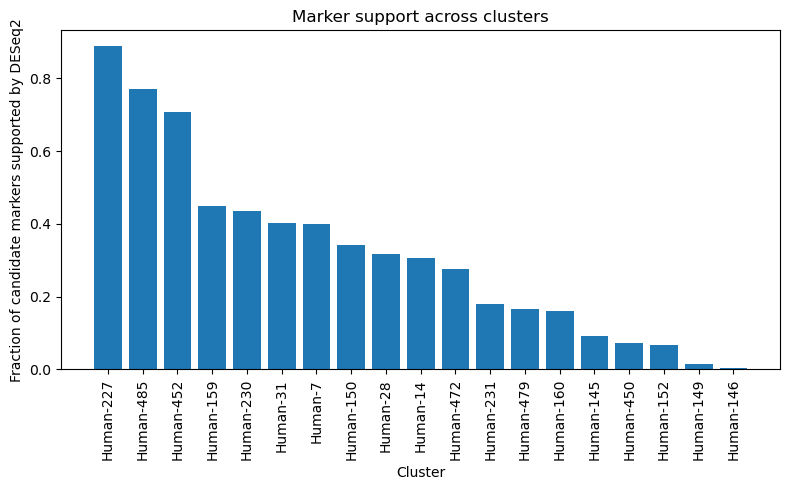

In [21]:
import matplotlib.pyplot as plt

df_plot = df_support.sort_values("support_fraction", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(df_plot["cluster"], df_plot["support_fraction"])
plt.xticks(rotation=90)
plt.ylabel("Fraction of candidate markers supported by DESeq2")
plt.xlabel("Cluster")
plt.title("Marker support across clusters")
plt.tight_layout()
plt.show()

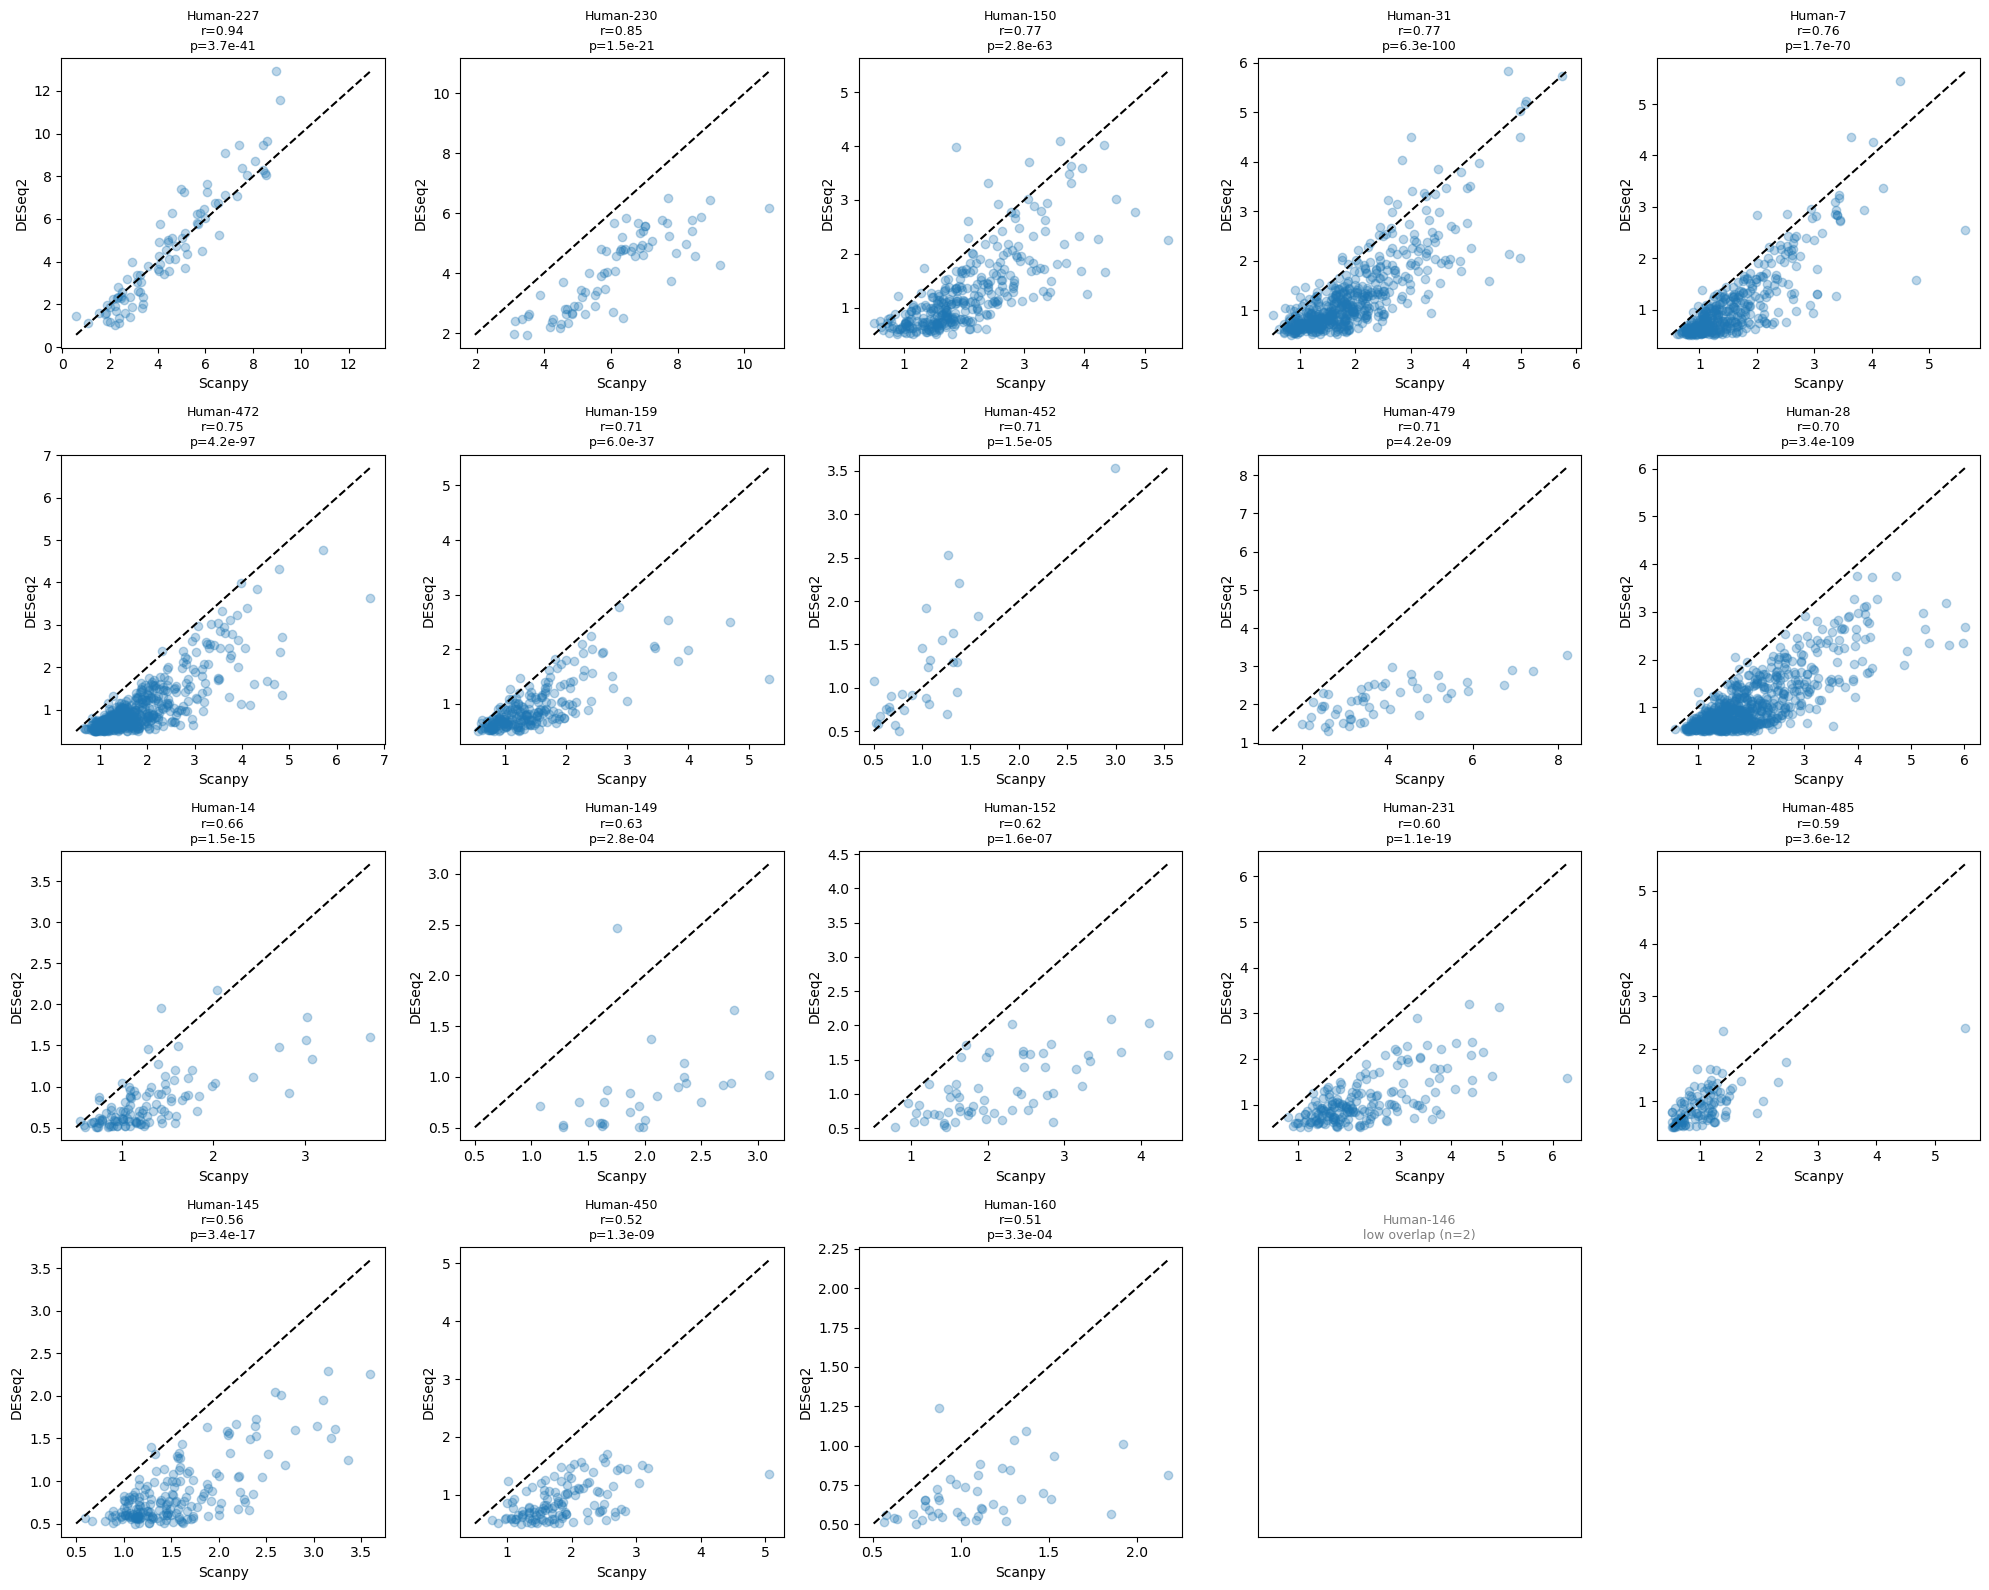

In [22]:
import matplotlib.pyplot as plt
import math
from scipy.stats import spearmanr

# -------- Step 1:  Spearman and order --------
cluster_stats = []

all_clusters = sorted(df_all_clusters_filtered["cluster"].unique())

for cl in all_clusters:
    df_deseq = df_all_deg[df_all_deg["cluster"] == cl]
    df_scanpy = df_all_clusters_filtered[df_all_clusters_filtered["cluster"] == cl]

    if df_deseq.empty or df_scanpy.empty:
        continue

    df_scanpy_tmp = df_scanpy.rename(columns={
        "names": "gene",
        "logfoldchanges": "logFC_scanpy"
    })
    df_deseq_tmp = df_deseq.rename(columns={
        "log2FoldChange": "logFC_deseq"
    })

    df_merge = pd.merge(df_scanpy_tmp, df_deseq_tmp, on="gene")

    if df_merge.shape[0] < 10:
        continue

    r, _ = spearmanr(df_merge["logFC_scanpy"], df_merge["logFC_deseq"])

    cluster_stats.append({
        "cluster": cl,
        "n_overlap": df_merge.shape[0],
        "spearman_r": r
    })

df_cluster_stats = pd.DataFrame(cluster_stats)

# order
df_cluster_stats = df_cluster_stats.sort_values("spearman_r", ascending=False)

clusters_sorted = df_cluster_stats["cluster"].tolist()

missing_clusters = [c for c in all_clusters if c not in clusters_sorted]
clusters_sorted += missing_clusters


# -------- Step2: plot --------
cols = 5
rows = math.ceil(len(clusters_sorted) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4)) 
axes = axes.flatten()

for i, cl in enumerate(clusters_sorted):
    ax = axes[i]

    df_deseq = df_all_deg[df_all_deg["cluster"] == cl]
    df_scanpy = df_all_clusters_filtered[df_all_clusters_filtered["cluster"] == cl]

    if df_deseq.empty or df_scanpy.empty:
        ax.text(0.5, 0.5, f"{cl}\n(no data)",
                ha='center', va='center', fontsize=9, color="gray")
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    df_scanpy = df_scanpy.rename(columns={
        "names": "gene",
        "logfoldchanges": "logFC_scanpy"
    })
    df_deseq = df_deseq.rename(columns={
        "log2FoldChange": "logFC_deseq"
    })

    df_merge = pd.merge(df_scanpy, df_deseq, on="gene")

    # -------- low overlap --------
    if df_merge.shape[0] < 10:
        ax.set_title(f"{cl}\nlow overlap (n={df_merge.shape[0]})",
                     fontsize=9, color="gray")

        ax.text(0.5, 0.5, "",
                ha='center', va='center',
                fontsize=9, color="gray")

        ax.set_xticks([])
        ax.set_yticks([])
        continue

    x = df_merge["logFC_scanpy"]
    y = df_merge["logFC_deseq"]

    ax.scatter(x, y, alpha=0.3)

    r, p = spearmanr(x, y)

    # format p-value
    if p < 1e-300:
        p_str = "<1e-300"
    else:
        p_str = f"{p:.1e}"

    # diagonal
    lims = [
        min(x.min(), y.min()),
        max(x.max(), y.max())
    ]
    ax.plot(lims, lims, 'k--')

    ax.set_title(f"{cl}\nr={r:.2f}\np={p_str}", fontsize=9)

    ax.set_xlabel("Scanpy")
    ax.set_ylabel("DESeq2")

    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig(
    "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/figures/spearman_cluster_scanpy_vs_deseq2_afterCB.pdf",
    bbox_inches="tight",
    dpi=400
)
plt.show()

In [28]:
df_cluster_stats #before CB

,cluster,n_overlap,spearman_r
0,Human-14,114,0.629283
1,Human-145,223,0.601791
2,Human-146,2,NaN
3,Human-149,41,0.624739
4,Human-150,341,0.801264
5,Human-152,68,0.584189
6,Human-159,278,0.763516
7,Human-160,52,0.567062
8,Human-227,284,0.880768
9,Human-230,76,0.803281


In [23]:
#df_cluster_stats #after CB
df_cluster_stats = df_cluster_stats.sort_index()
df_cluster_stats #cluster 452， 227 changed a lot; others not.

,cluster,n_overlap,spearman_r
0,Human-14,114,0.659448
1,Human-145,189,0.562893
2,Human-149,29,0.625616
3,Human-150,319,0.767873
4,Human-152,60,0.615949
5,Human-159,228,0.714718
6,Human-160,45,0.511726
7,Human-227,87,0.938981
8,Human-230,73,0.851197
9,Human-231,191,0.595181


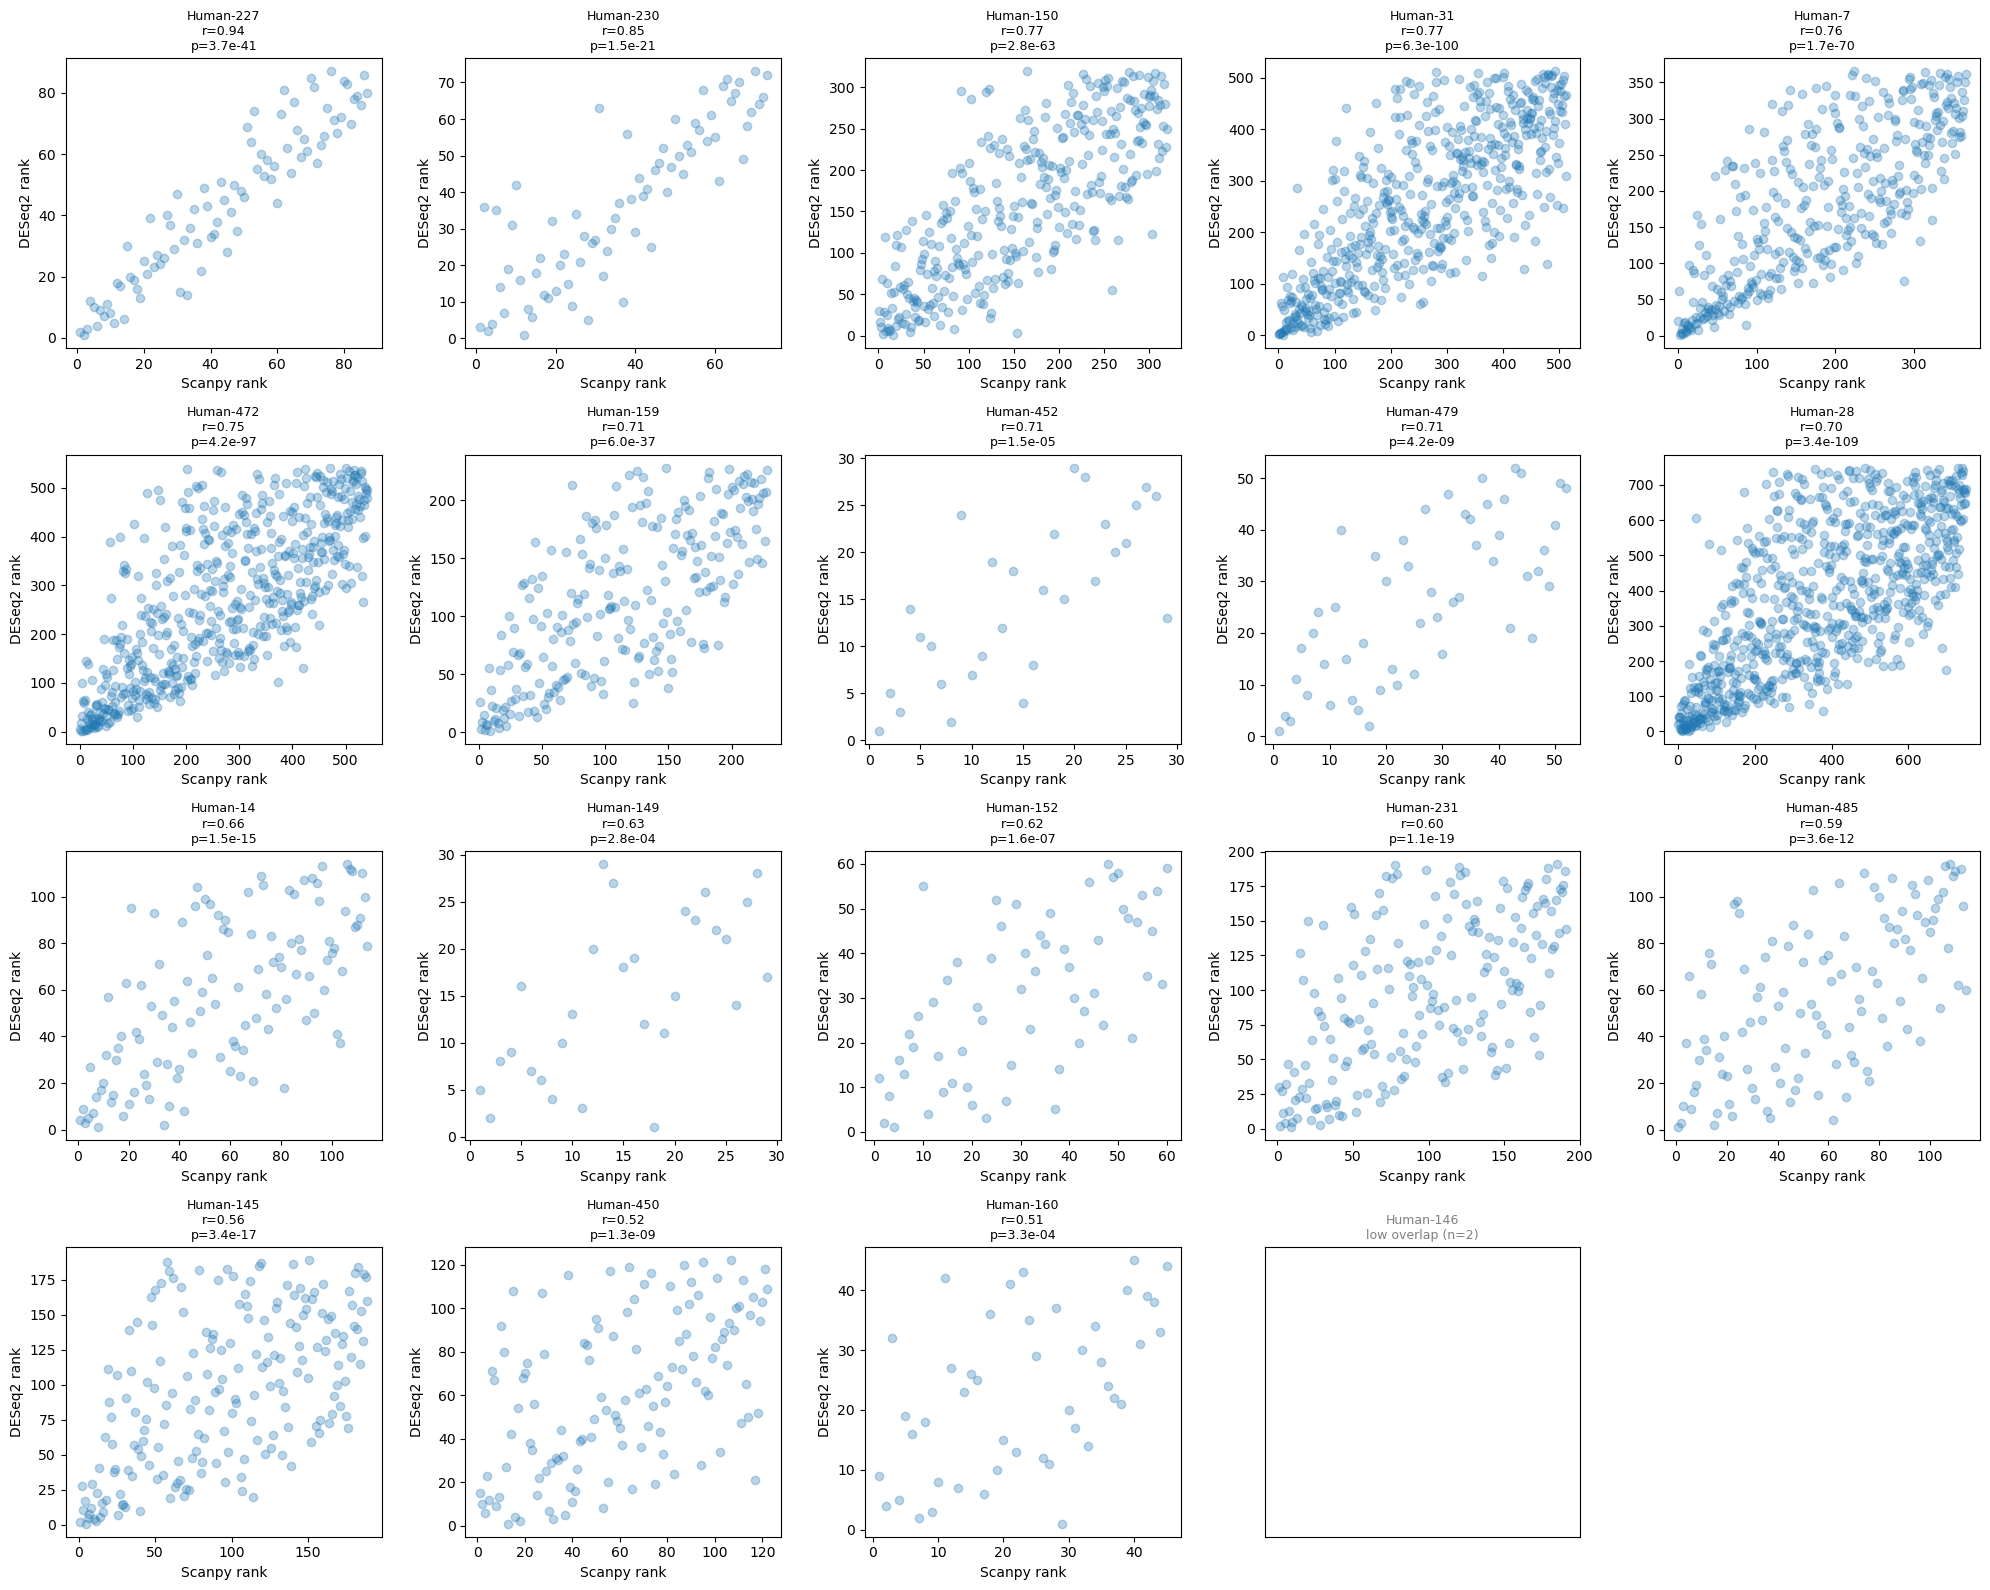

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import spearmanr

# -------- Step 1: compute rank-based correlation --------
cluster_stats = []

all_clusters = sorted(df_all_clusters_filtered["cluster"].unique())

for cl in all_clusters:
    df_deseq = df_all_deg[df_all_deg["cluster"] == cl]
    df_scanpy = df_all_clusters_filtered[df_all_clusters_filtered["cluster"] == cl]

    if df_deseq.empty or df_scanpy.empty:
        continue

    df_scanpy_tmp = df_scanpy.rename(columns={
        "names": "gene",
        "logfoldchanges": "logFC_scanpy"
    })
    df_deseq_tmp = df_deseq.rename(columns={
        "log2FoldChange": "logFC_deseq"
    })

    df_merge = pd.merge(df_scanpy_tmp, df_deseq_tmp, on="gene")

    if df_merge.shape[0] < 10:
        continue

    # -------- rank transform --------
    df_merge["rank_scanpy"] = df_merge["logFC_scanpy"].rank(ascending=False)
    df_merge["rank_deseq"] = df_merge["logFC_deseq"].rank(ascending=False)

    r, p = spearmanr(df_merge["rank_scanpy"], df_merge["rank_deseq"])

    cluster_stats.append({
        "cluster": cl,
        "n_overlap": df_merge.shape[0],
        "spearman_r": r,
        "pval": p
    })

df_cluster_stats = pd.DataFrame(cluster_stats)

# -------- order clusters --------
df_cluster_stats = df_cluster_stats.sort_values("spearman_r", ascending=False)
clusters_sorted = df_cluster_stats["cluster"].tolist()

missing_clusters = [c for c in all_clusters if c not in clusters_sorted]
clusters_sorted += missing_clusters

# -------- Step 2: plotting --------
cols = 5
rows = math.ceil(len(clusters_sorted) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
axes = axes.flatten()

for i, cl in enumerate(clusters_sorted):
    ax = axes[i]

    df_deseq = df_all_deg[df_all_deg["cluster"] == cl]
    df_scanpy = df_all_clusters_filtered[df_all_clusters_filtered["cluster"] == cl]

    if df_deseq.empty or df_scanpy.empty:
        ax.text(0.5, 0.5, f"{cl}\n(no data)",
                ha='center', va='center', fontsize=9, color="gray")
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    df_scanpy = df_scanpy.rename(columns={
        "names": "gene",
        "logfoldchanges": "logFC_scanpy"
    })
    df_deseq = df_deseq.rename(columns={
        "log2FoldChange": "logFC_deseq"
    })

    df_merge = pd.merge(df_scanpy, df_deseq, on="gene")

    if df_merge.shape[0] < 10:
        ax.set_title(f"{cl}\nlow overlap (n={df_merge.shape[0]})",
                     fontsize=9, color="gray")
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    # -------- rank transform --------
    df_merge["rank_scanpy"] = df_merge["logFC_scanpy"].rank(ascending=False)
    df_merge["rank_deseq"] = df_merge["logFC_deseq"].rank(ascending=False)

    x = df_merge["rank_scanpy"]
    y = df_merge["rank_deseq"]

    ax.scatter(x, y, alpha=0.3)

    r, p = spearmanr(x, y)

    # p-value format
    if p < 1e-300:
        p_str = "<1e-300"
    else:
        p_str = f"{p:.1e}"

    ax.set_title(f"{cl}\nr={r:.2f}\np={p_str}", fontsize=9)

    ax.set_xlabel("Scanpy rank")
    ax.set_ylabel("DESeq2 rank")

# remove empty panels
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig(
    "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/rank_spearman_cluster_scanpy_vs_deseq2_afterCB.pdf",
    bbox_inches="tight",
    dpi=400
)

plt.show()

In [25]:
# ================================
# Additional: gene-level overlap table
# ================================

overlap_rows = []

for cl in clusters_sorted:
    df_deseq = df_all_deg[df_all_deg["cluster"] == cl]
    df_scanpy = df_all_clusters_filtered[df_all_clusters_filtered["cluster"] == cl]

    if df_deseq.empty or df_scanpy.empty:
        continue

    # --- rename for merge ---
    df_scanpy_tmp = df_scanpy.rename(columns={
        "names": "gene"
    }).copy()

    df_deseq_tmp = df_deseq.rename(columns={
        "log2FoldChange": "logFC_deseq"
    }).copy()

    # --- merge ---
    df_merge = pd.merge(df_scanpy_tmp, df_deseq_tmp, on="gene")
    df_merge["cluster"] = cl

    if df_merge.empty:
        continue

    # --- add prefixes ---
    scanpy_cols = [c for c in df_scanpy_tmp.columns if c not in ["gene", "cluster"]]
    deseq_cols = [c for c in df_deseq_tmp.columns if c not in ["gene", "cluster"]]

    df_merge_prefixed = df_merge.copy()

    for c in scanpy_cols:
        if c in df_merge_prefixed.columns:
            df_merge_prefixed.rename(columns={c: f"scanpy_wilcoxon_{c}"}, inplace=True)

    for c in deseq_cols:
        if c in df_merge_prefixed.columns:
            df_merge_prefixed.rename(columns={c: f"pseudobulk_DESeq2_{c}"}, inplace=True)

    # --- keep cluster + gene first ---
    cols = ["cluster", "gene"] + [c for c in df_merge_prefixed.columns if c not in ["cluster", "gene"]]
    df_merge_prefixed = df_merge_prefixed[cols]

    overlap_rows.append(df_merge_prefixed)


# concat all clusters
df_overlap_full = pd.concat(overlap_rows, ignore_index=True) if overlap_rows else pd.DataFrame()

# save
df_overlap_full.to_csv("/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Cluster_level_DEGs_overlap-wilcoxon-DEseq2_afterCB.csv", index=False)

print("Saved gene-level overlap table:", df_overlap_full.shape)

Saved gene-level overlap table: (3821, 19)


In [26]:
low_clusters = []

for cl in clusters_sorted:
    df_deseq = df_all_deg[df_all_deg["cluster"] == cl]
    df_scanpy = df_all_clusters_filtered[df_all_clusters_filtered["cluster"] == cl]

    df_merge = pd.merge(
        df_scanpy.rename(columns={"names": "gene"}),
        df_deseq,
        on="gene"
    )

    if 0 < df_merge.shape[0] < 10:
        print(f"{cl}: {df_merge.shape[0]} genes")
        low_clusters.append(df_merge.assign(cluster=cl))

## these two genes in csv but not in plot
df_low = pd.concat(low_clusters)
print(df_low[["cluster", "gene"]])

Human-146: 2 genes
     cluster        gene
0  Human-146  AL356488.2
1  Human-146       ZNF98


In [27]:
3821/4535 #before CB, all_df_overlap 4535

0.8425578831312017

## 1.4 add supported_after_CellBender_by_both_methods column to Table S1

In [28]:
import pandas as pd

# -----------------------------
# Input files
# -----------------------------
primary_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Cluster_level_DEGs_overlap-wilcoxon-DEseq2.csv"
cellbender_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Cluster_level_DEGs_overlap-wilcoxon-DEseq2_afterCB.csv"

# -----------------------------
# Output files
# -----------------------------
output_xlsx = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Cluster_level_DEGs_overlap-wilcoxon-DEseq2_with_CellBender_support.xlsx"
#output_csv = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Cluster_level_DEGs_overlap-wilcoxon-DEseq2_with_CellBender_support.csv"

# -----------------------------
# Read tables
# -----------------------------
primary = pd.read_csv(primary_file)
cb = pd.read_csv(cellbender_file)

# -----------------------------
# Basic checks
# -----------------------------
required_cols = ["cluster", "gene"]

for df_name, df in [("primary", primary), ("cellbender", cb)]:
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{df_name} table is missing required columns: {missing}")

# Use string keys to avoid category/object mismatch
primary["cluster"] = primary["cluster"].astype(str)
primary["gene"] = primary["gene"].astype(str)

cb["cluster"] = cb["cluster"].astype(str)
cb["gene"] = cb["gene"].astype(str)

# -----------------------------
# Build cluster-gene keys
# -----------------------------
primary_key = primary["cluster"] + "||" + primary["gene"]
cb_key = set(cb["cluster"] + "||" + cb["gene"])

# -----------------------------
# Add CellBender support column
# -----------------------------
primary["supported_after_CellBender_by_both_methods"] = primary_key.isin(cb_key).map({
    True: "yes",
    False: "no"
})


# -----------------------------
# Summary
# -----------------------------
n_total = primary.shape[0]
n_retained = (primary["supported_after_CellBender_by_both_methods"] == "yes").sum()
retained_pct = n_retained / n_total * 100

print(f"Primary both-overlap markers: {n_total}")
print(f"Retained after CellBender: {n_retained}")
print(f"Retained percentage: {retained_pct:.1f}%")

# Per-cluster summary
cluster_summary = (
    primary
    .groupby("cluster")
    .agg(
        primary_both_overlap_markers=("gene", "count"),
        retained_after_CellBender=("supported_after_CellBender_by_both_methods", lambda x: (x == "yes").sum())
    )
    .reset_index()
)

cluster_summary["retained_percentage"] = (
    cluster_summary["retained_after_CellBender"]
    / cluster_summary["primary_both_overlap_markers"]
    * 100
)

print(cluster_summary.sort_values("retained_percentage").to_string(index=False))

# -----------------------------
# Save updated table
# -----------------------------
#primary.to_csv(output_csv, index=False)

with pd.ExcelWriter(output_xlsx, engine="openpyxl") as writer:
    primary.to_excel(writer, sheet_name="both_overlap", index=False)
    cluster_summary.to_excel(writer, sheet_name="CellBender_summary", index=False)

#print(f"Saved: {output_csv}")
print(f"Saved: {output_xlsx}")

Primary both-overlap markers: 4535
Retained after CellBender: 3416
Retained percentage: 75.3%
  cluster  primary_both_overlap_markers  retained_after_CellBender  retained_percentage
Human-452                           312                         21             6.730769
Human-227                           284                         82            28.873239
Human-149                            41                         27            65.853659
Human-479                            74                         52            70.270270
Human-152                            68                         52            76.470588
Human-450                           130                        100            76.923077
Human-159                           278                        219            78.776978
Human-231                           217                        173            79.723502
Human-145                           223                        178            79.820628
Human-472                 

### DEseq2 comparison before vs after cellbender -> reponse to Reviewer 1

  cluster  primary_DESeq2_markers  CellBender_DESeq2_markers  retained_marker_count_difference  CellBender_vs_primary_percentage
  Human-7                     730                        706                               -24                         96.712329
 Human-14                     187                        192                                 5                        102.673797
 Human-28                    1227                       1142                               -85                         93.072535
 Human-31                     955                        772                              -183                         80.837696
Human-145                     402                        320                               -82                         79.601990
Human-146                       2                          3                                 1                        150.000000
Human-149                      47                         30                               -17   

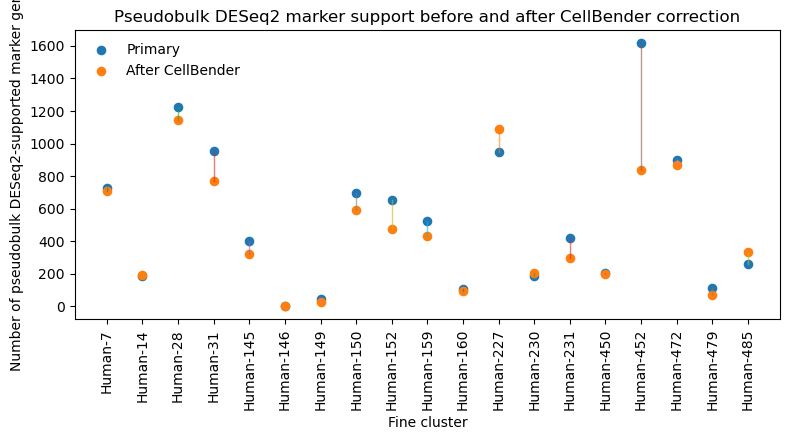

Saved figure: /home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_marker_count_before_after_CellBender.pdf
Saved figure: /home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_marker_count_before_after_CellBender.png


In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Input files
# -----------------------------
primary_deseq2_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Cluster_DEGs_within_subgroup_pseudobulk-DESeq2.csv"
cellbender_deseq2_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Cluster_DEGs_within_subgroup_pseudobulk-DESeq2_afterCB.csv"

# -----------------------------
# Output files
# -----------------------------
output_summary_csv = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_marker_count_before_after_CellBender_summary.csv"
output_fig_pdf = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_marker_count_before_after_CellBender.pdf"
output_fig_png = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_marker_count_before_after_CellBender.png"

# -----------------------------
# Read tables
# -----------------------------
primary = pd.read_csv(primary_deseq2_file)
cb = pd.read_csv(cellbender_deseq2_file)

# -----------------------------
# Basic checks
# -----------------------------
required_cols = ["cluster", "gene"]

for df_name, df in [("primary", primary), ("cellbender", cb)]:
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{df_name} table is missing required columns: {missing}")

primary["cluster"] = primary["cluster"].astype(str)
primary["gene"] = primary["gene"].astype(str)

cb["cluster"] = cb["cluster"].astype(str)
cb["gene"] = cb["gene"].astype(str)

# -----------------------------
# Count DESeq2-supported markers per cluster
# -----------------------------
primary_counts = (
    primary
    .groupby("cluster")["gene"]
    .nunique()
    .rename("primary_DESeq2_markers")
)

cb_counts = (
    cb
    .groupby("cluster")["gene"]
    .nunique()
    .rename("CellBender_DESeq2_markers")
)

summary = (
    pd.concat([primary_counts, cb_counts], axis=1)
    .fillna(0)
    .astype(int)
    .reset_index()
)

summary["retained_marker_count_difference"] = (
    summary["CellBender_DESeq2_markers"] - summary["primary_DESeq2_markers"]
)

summary["CellBender_vs_primary_percentage"] = (
    summary["CellBender_DESeq2_markers"]
    / summary["primary_DESeq2_markers"].replace(0, pd.NA)
    * 100
)

# Optional: sort clusters by numeric part if clusters are like Human-7
def cluster_sort_key(x):
    try:
        return int(str(x).split("-")[-1])
    except Exception:
        return str(x)

summary = summary.sort_values(
    by="cluster",
    key=lambda s: s.map(cluster_sort_key)
).reset_index(drop=True)

summary.to_csv(output_summary_csv, index=False)

print(summary.to_string(index=False))
print(f"Saved summary: {output_summary_csv}")

# -----------------------------
# Plot paired before/after marker counts
# -----------------------------
x = range(summary.shape[0])

plt.figure(figsize=(max(8, summary.shape[0] * 0.35), 4.5))

for i, row in summary.iterrows():
    plt.plot(
        [i, i],
        [row["primary_DESeq2_markers"], row["CellBender_DESeq2_markers"]],
        linewidth=1,
        alpha=0.6
    )

plt.scatter(
    x,
    summary["primary_DESeq2_markers"],
    label="Primary",
    s=35
)

plt.scatter(
    x,
    summary["CellBender_DESeq2_markers"],
    label="After CellBender",
    s=35
)

plt.xticks(
    ticks=list(x),
    labels=summary["cluster"],
    rotation=90
)

plt.ylabel("Number of pseudobulk DESeq2-supported marker genes")
plt.xlabel("Fine cluster")
plt.title("Pseudobulk DESeq2 marker support before and after CellBender correction")
plt.legend(frameon=False)
plt.tight_layout()

plt.savefig(output_fig_pdf, bbox_inches="tight")
plt.savefig(output_fig_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure: {output_fig_pdf}")
print(f"Saved figure: {output_fig_png}")

                               metric        value
          primary_DESeq2_marker_pairs 10176.000000
       CellBender_DESeq2_marker_pairs  8658.000000
                  shared_marker_pairs  7360.000000
            primary_only_marker_pairs  2816.000000
         CellBender_only_marker_pairs  1298.000000
Spearman_log2FC_primary_vs_CellBender     0.957905
 Pearson_log2FC_primary_vs_CellBender     0.872326


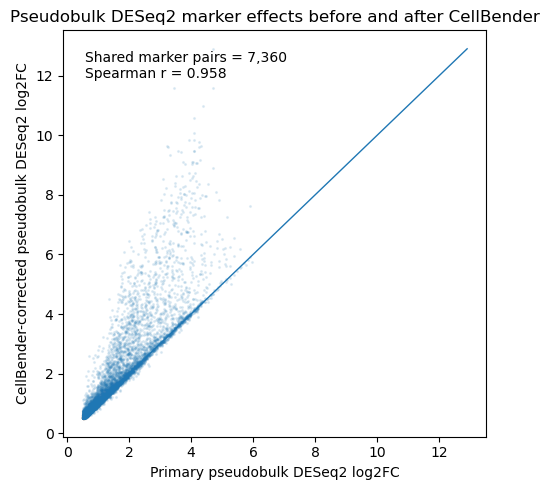

Saved figure: /home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_log2FC_before_after_CellBender.pdf
Saved summary: /home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_log2FC_before_after_CellBender_summary.csv


In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Input files
# -----------------------------
primary_deseq2_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Cluster_DEGs_within_subgroup_pseudobulk-DESeq2.csv"
cellbender_deseq2_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Cluster_DEGs_within_subgroup_pseudobulk-DESeq2_afterCB.csv"

# -----------------------------
# Output files
# -----------------------------
output_fig_pdf = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_log2FC_before_after_CellBender.pdf"
#output_fig_png = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_log2FC_before_after_CellBender.png"
output_summary_csv = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_log2FC_before_after_CellBender_summary.csv"

# -----------------------------
# Read tables
# -----------------------------
primary = pd.read_csv(primary_deseq2_file)
cb = pd.read_csv(cellbender_deseq2_file)

for df in [primary, cb]:
    df["cluster"] = df["cluster"].astype(str)
    df["gene"] = df["gene"].astype(str)

# -----------------------------
# Merge matched cluster-gene pairs
# -----------------------------
merged = primary.merge(
    cb,
    on=["cluster", "gene"],
    suffixes=("_primary", "_CellBender")
)

# -----------------------------
# Summary statistics
# -----------------------------
n_primary = primary[["cluster", "gene"]].drop_duplicates().shape[0]
n_cb = cb[["cluster", "gene"]].drop_duplicates().shape[0]
n_shared = merged[["cluster", "gene"]].drop_duplicates().shape[0]

spearman_r = merged[["log2FoldChange_primary", "log2FoldChange_CellBender"]].corr(
    method="spearman"
).iloc[0, 1]

pearson_r = merged[["log2FoldChange_primary", "log2FoldChange_CellBender"]].corr(
    method="pearson"
).iloc[0, 1]

summary = pd.DataFrame({
    "metric": [
        "primary_DESeq2_marker_pairs",
        "CellBender_DESeq2_marker_pairs",
        "shared_marker_pairs",
        "primary_only_marker_pairs",
        "CellBender_only_marker_pairs",
        "Spearman_log2FC_primary_vs_CellBender",
        "Pearson_log2FC_primary_vs_CellBender"
    ],
    "value": [
        n_primary,
        n_cb,
        n_shared,
        n_primary - n_shared,
        n_cb - n_shared,
        spearman_r,
        pearson_r
    ]
})

summary.to_csv(output_summary_csv, index=False)
print(summary.to_string(index=False))

# -----------------------------
# Plot log2FC before vs after
# -----------------------------
plt.figure(figsize=(5, 5))

plt.scatter(
    merged["log2FoldChange_primary"],
    merged["log2FoldChange_CellBender"],
    s=1.5,
    alpha=0.1
)

min_val = min(
    merged["log2FoldChange_primary"].min(),
    merged["log2FoldChange_CellBender"].min()
)

max_val = max(
    merged["log2FoldChange_primary"].max(),
    merged["log2FoldChange_CellBender"].max()
)

plt.plot([min_val, max_val], [min_val, max_val], linewidth=1)

plt.xlabel("Primary pseudobulk DESeq2 log2FC")
plt.ylabel("CellBender-corrected pseudobulk DESeq2 log2FC")
plt.title("Pseudobulk DESeq2 marker effects before and after CellBender")

plt.text(
    0.05,
    0.95,
    f"Shared marker pairs = {n_shared:,}\nSpearman r = {spearman_r:.3f}",
    transform=plt.gca().transAxes,
    va="top"
)

plt.tight_layout()
plt.savefig(output_fig_pdf, bbox_inches="tight")
#plt.savefig(output_fig_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure: {output_fig_pdf}")
#print(f"Saved figure: {output_fig_png}")
print(f"Saved summary: {output_summary_csv}")

                                     metric        value
                primary_DESeq2_marker_pairs 10176.000000
             CellBender_DESeq2_marker_pairs  8658.000000
                        shared_marker_pairs  7360.000000
                  primary_only_marker_pairs  2816.000000
               CellBender_only_marker_pairs  1298.000000
      Spearman_log2FC_primary_vs_CellBender     0.957905
       Pearson_log2FC_primary_vs_CellBender     0.872326
Spearman_neglog10padj_primary_vs_CellBender     0.848676
 Pearson_neglog10padj_primary_vs_CellBender     0.876406


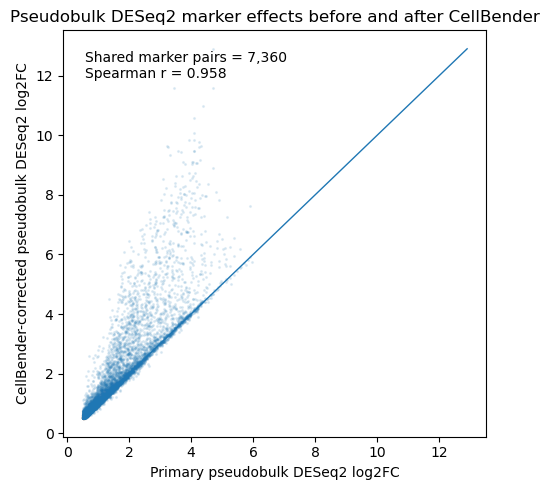

Saved log2FC figure: /home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_cluster_log2FC_before_after_CellBender.pdf


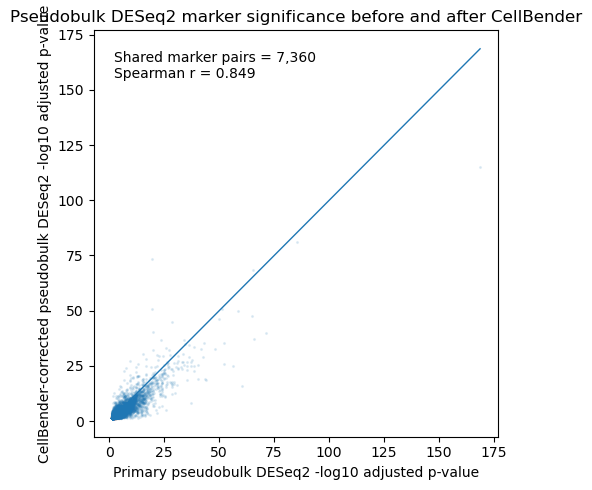

Saved padj figure: /home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_cluster_neglog10padj_before_after_CellBender.pdf
Saved summary: /home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_cluster_before_after_CellBender_summary.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Input files
# -----------------------------
primary_deseq2_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Cluster_DEGs_within_subgroup_pseudobulk-DESeq2.csv"
cellbender_deseq2_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Cluster_DEGs_within_subgroup_pseudobulk-DESeq2_afterCB.csv"

# -----------------------------
# Output files
# -----------------------------
output_fig_pdf = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_cluster_log2FC_before_after_CellBender.pdf"
output_fig_padj_pdf = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_cluster_neglog10padj_before_after_CellBender.pdf"
output_summary_csv = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_cluster_before_after_CellBender_summary.csv"

# -----------------------------
# Read tables
# -----------------------------
primary = pd.read_csv(primary_deseq2_file)
cb = pd.read_csv(cellbender_deseq2_file)

for df in [primary, cb]:
    df["cluster"] = df["cluster"].astype(str)
    df["gene"] = df["gene"].astype(str)

# -----------------------------
# Merge matched cluster-gene pairs
# -----------------------------
merged = primary.merge(
    cb,
    on=["cluster", "gene"],
    suffixes=("_primary", "_CellBender")
)

# -----------------------------
# Summary statistics
# -----------------------------
n_primary = primary[["cluster", "gene"]].drop_duplicates().shape[0]
n_cb = cb[["cluster", "gene"]].drop_duplicates().shape[0]
n_shared = merged[["cluster", "gene"]].drop_duplicates().shape[0]

spearman_r = merged[["log2FoldChange_primary", "log2FoldChange_CellBender"]].corr(
    method="spearman"
).iloc[0, 1]

pearson_r = merged[["log2FoldChange_primary", "log2FoldChange_CellBender"]].corr(
    method="pearson"
).iloc[0, 1]

# -----------------------------
# Compute -log10 adjusted p-values
# -----------------------------
eps = 1e-300

merged["neglog10_padj_primary"] = -np.log10(
    merged["padj_primary"].clip(lower=eps)
)

merged["neglog10_padj_CellBender"] = -np.log10(
    merged["padj_CellBender"].clip(lower=eps)
)

spearman_padj = merged[["neglog10_padj_primary", "neglog10_padj_CellBender"]].corr(
    method="spearman"
).iloc[0, 1]

pearson_padj = merged[["neglog10_padj_primary", "neglog10_padj_CellBender"]].corr(
    method="pearson"
).iloc[0, 1]

summary = pd.DataFrame({
    "metric": [
        "primary_DESeq2_marker_pairs",
        "CellBender_DESeq2_marker_pairs",
        "shared_marker_pairs",
        "primary_only_marker_pairs",
        "CellBender_only_marker_pairs",
        "Spearman_log2FC_primary_vs_CellBender",
        "Pearson_log2FC_primary_vs_CellBender",
        "Spearman_neglog10padj_primary_vs_CellBender",
        "Pearson_neglog10padj_primary_vs_CellBender"
    ],
    "value": [
        n_primary,
        n_cb,
        n_shared,
        n_primary - n_shared,
        n_cb - n_shared,
        spearman_r,
        pearson_r,
        spearman_padj,
        pearson_padj
    ]
})

summary.to_csv(output_summary_csv, index=False)
print(summary.to_string(index=False))

# -----------------------------
# Plot log2FC before vs after
# -----------------------------
plt.figure(figsize=(5, 5))

plt.scatter(
    merged["log2FoldChange_primary"],
    merged["log2FoldChange_CellBender"],
    s=1.5,
    alpha=0.1
)

min_val = min(
    merged["log2FoldChange_primary"].min(),
    merged["log2FoldChange_CellBender"].min()
)

max_val = max(
    merged["log2FoldChange_primary"].max(),
    merged["log2FoldChange_CellBender"].max()
)

plt.plot([min_val, max_val], [min_val, max_val], linewidth=1)

plt.xlabel("Primary pseudobulk DESeq2 log2FC")
plt.ylabel("CellBender-corrected pseudobulk DESeq2 log2FC")
plt.title("Pseudobulk DESeq2 marker effects before and after CellBender")

plt.text(
    0.05,
    0.95,
    f"Shared marker pairs = {n_shared:,}\nSpearman r = {spearman_r:.3f}",
    transform=plt.gca().transAxes,
    va="top"
)

plt.tight_layout()
plt.savefig(output_fig_pdf, bbox_inches="tight")
plt.show()

print(f"Saved log2FC figure: {output_fig_pdf}")

# -----------------------------
# Plot adjusted p-values before vs after
# -----------------------------
plt.figure(figsize=(5, 5))

plt.scatter(
    merged["neglog10_padj_primary"],
    merged["neglog10_padj_CellBender"],
    s=1.5,
    alpha=0.1
)

min_val = min(
    merged["neglog10_padj_primary"].min(),
    merged["neglog10_padj_CellBender"].min()
)

max_val = max(
    merged["neglog10_padj_primary"].max(),
    merged["neglog10_padj_CellBender"].max()
)

plt.plot([min_val, max_val], [min_val, max_val], linewidth=1)

plt.xlabel("Primary pseudobulk DESeq2 -log10 adjusted p-value")
plt.ylabel("CellBender-corrected pseudobulk DESeq2 -log10 adjusted p-value")
plt.title("Pseudobulk DESeq2 marker significance before and after CellBender")

plt.text(
    0.05,
    0.95,
    f"Shared marker pairs = {n_shared:,}\nSpearman r = {spearman_padj:.3f}",
    transform=plt.gca().transAxes,
    va="top"
)

plt.tight_layout()
plt.savefig(output_fig_padj_pdf, bbox_inches="tight")
plt.show()

print(f"Saved padj figure: {output_fig_padj_pdf}")
print(f"Saved summary: {output_summary_csv}")

In [1]:
import pandas as pd

# -----------------------------
# Input files
# -----------------------------
primary_deseq2_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Cluster_DEGs_within_subgroup_pseudobulk-DESeq2.csv"
cellbender_deseq2_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Cluster_DEGs_within_subgroup_pseudobulk-DESeq2_afterCB.csv"

# -----------------------------
# Output file
# -----------------------------
output_table_s1 = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Table_S1_DESeq2_markers_retained_after_CellBender.csv"

# -----------------------------
# Read tables
# -----------------------------
primary = pd.read_csv(primary_deseq2_file)
cb = pd.read_csv(cellbender_deseq2_file)

for df in [primary, cb]:
    df["cluster"] = df["cluster"].astype(str)
    df["gene"] = df["gene"].astype(str)

# -----------------------------
# Keep CellBender columns to append
# -----------------------------
cb_cols_to_add = [
    "cluster",
    "gene",
    "baseMean",
    "log2FoldChange",
    "lfcSE",
    "stat",
    "pvalue",
    "padj"
]

# Only keep columns that actually exist
cb_cols_to_add = [c for c in cb_cols_to_add if c in cb.columns]

cb_add = cb[cb_cols_to_add].copy()

# Rename CellBender statistics
rename_cb = {
    "baseMean": "CellBender_baseMean",
    "log2FoldChange": "CellBender_log2FoldChange",
    "lfcSE": "CellBender_lfcSE",
    "stat": "CellBender_stat",
    "pvalue": "CellBender_pvalue",
    "padj": "CellBender_padj"
}

cb_add = cb_add.rename(columns=rename_cb)

# -----------------------------
# Merge: primary table as main body
# -----------------------------
table_s1 = primary.merge(
    cb_add,
    on=["cluster", "gene"],
    how="inner"
)

# -----------------------------
# Optional: rename primary DESeq2 columns for clarity
# -----------------------------
rename_primary = {
    "baseMean": "primary_baseMean",
    "log2FoldChange": "primary_log2FoldChange",
    "lfcSE": "primary_lfcSE",
    "stat": "primary_stat",
    "pvalue": "primary_pvalue",
    "padj": "primary_padj"
}

table_s1 = table_s1.rename(columns=rename_primary)

# -----------------------------
# Optional: add effect-size change columns
# -----------------------------
if {"primary_log2FoldChange", "CellBender_log2FoldChange"}.issubset(table_s1.columns):
    table_s1["delta_log2FoldChange_CellBender_minus_primary"] = (
        table_s1["CellBender_log2FoldChange"] - table_s1["primary_log2FoldChange"]
    )
    table_s1["abs_delta_log2FoldChange"] = table_s1[
        "delta_log2FoldChange_CellBender_minus_primary"
    ].abs()

    table_s1["same_log2FC_direction"] = (
        table_s1["primary_log2FoldChange"] * table_s1["CellBender_log2FoldChange"] > 0
    )

# -----------------------------
# Optional: sort for readability
# -----------------------------
sort_cols = [c for c in ["cluster", "primary_padj", "gene"] if c in table_s1.columns]
table_s1 = table_s1.sort_values(sort_cols)

# -----------------------------
# Save
# -----------------------------
table_s1.to_csv(output_table_s1, index=False)

print("Saved:", output_table_s1)
print("Rows in Table S1:", table_s1.shape[0])
print("Columns in Table S1:", table_s1.shape[1])

if "same_log2FC_direction" in table_s1.columns:
    print("Same direction:", table_s1["same_log2FC_direction"].sum())
    print("Different direction:", (~table_s1["same_log2FC_direction"]).sum())

table_s1.head()

Saved: /home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Table_S1_DESeq2_markers_retained_after_CellBender.csv
Rows in Table S1: 7360
Columns in Table S1: 19
Same direction: 7360
Different direction: 0


,primary_baseMean,primary_log2FoldChange,primary_lfcSE,primary_stat,primary_pvalue,primary_padj,gene,subgroup,cluster,n_donors_used,CellBender_baseMean,CellBender_log2FoldChange,CellBender_lfcSE,CellBender_stat,CellBender_pvalue,CellBender_padj,delta_log2FoldChange_CellBender_minus_primary,abs_delta_log2FoldChange,same_log2FC_direction
135,560.809612,0.958644,0.100302,9.557567,1.205572e-21,1.804412e-18,SLC14A1,GM STR,Human-14,9,544.106596,0.954259,0.103531,9.217108,3.052204e-20,5.442757e-17,-0.004385,0.004385,True
46,255.570278,0.895408,0.103841,8.622863,6.530070e-18,7.167405e-15,AC124854.1,GM STR,Human-14,9,254.981026,0.889407,0.106188,8.375747,5.487454e-17,5.504260e-14,-0.006001,0.006001,True
38,3164.048607,0.867202,0.101900,8.510304,1.734772e-17,1.680076e-14,GRID2,GM STR,Human-14,9,2955.637352,0.918953,0.104854,8.764123,1.882355e-18,3.020992e-15,0.051751,0.051751,True
76,164.420180,1.494435,0.186185,8.026626,1.001903e-15,7.171883e-13,ADRA1A,GM STR,Human-14,9,162.583227,1.485708,0.196310,7.568187,3.784699e-14,2.530860e-11,-0.008727,0.008727,True
133,647.563669,1.036978,0.130376,7.953721,1.809910e-15,1.191934e-12,SLC39A11,GM STR,Human-14,9,642.932307,1.043080,0.139763,7.463217,8.443484e-14,4.516982e-11,0.006102,0.006102,True


In [14]:
import pandas as pd

# -----------------------------
# Input files
# -----------------------------
primary_deseq2_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Cluster_DEGs_within_subgroup_pseudobulk-DESeq2.csv"

# Use all tested genes after CellBender, not sig-only table
cellbender_deseq2_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Cluster_DEGs_within_subgroup_pseudobulk-DESeq2_afterCB_all_genes.csv"

# -----------------------------
# Output file
# -----------------------------
output_table_s1 = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Table_S1_DESeq2_primary_markers_with_CellBender_stats.csv"

# -----------------------------
# Read tables
# -----------------------------
primary = pd.read_csv(primary_deseq2_file)
cb = pd.read_csv(cellbender_deseq2_file)

for df in [primary, cb]:
    df["cluster"] = df["cluster"].astype(str)
    df["gene"] = df["gene"].astype(str)

# -----------------------------
# Optional safety check: include subgroup if present
# -----------------------------
merge_keys = ["cluster", "gene"]
if "subgroup" in primary.columns and "subgroup" in cb.columns:
    primary["subgroup"] = primary["subgroup"].astype(str)
    cb["subgroup"] = cb["subgroup"].astype(str)
    merge_keys = ["subgroup", "cluster", "gene"]

# -----------------------------
# Keep CellBender columns to append
# -----------------------------
cb_cols_to_add = merge_keys + [
    "baseMean",
    "log2FoldChange",
    "lfcSE",
    "stat",
    "pvalue",
    "padj",
    "n_donors_used",
]

cb_cols_to_add = [c for c in cb_cols_to_add if c in cb.columns]

cb_add = cb[cb_cols_to_add].copy()

# Rename CellBender statistics
rename_cb = {
    "baseMean": "CellBender_baseMean",
    "log2FoldChange": "CellBender_log2FoldChange",
    "lfcSE": "CellBender_lfcSE",
    "stat": "CellBender_stat",
    "pvalue": "CellBender_pvalue",
    "padj": "CellBender_padj",
    "n_donors_used": "CellBender_n_donors_used",
}

cb_add = cb_add.rename(columns=rename_cb)

# -----------------------------
# Merge: primary table as main body
# Keep ALL primary markers
# -----------------------------
table_s1 = primary.merge(
    cb_add,
    on=merge_keys,
    how="left"
)

# -----------------------------
# Rename primary DESeq2 columns for clarity
# -----------------------------
rename_primary = {
    "baseMean": "primary_baseMean",
    "log2FoldChange": "primary_log2FoldChange",
    "lfcSE": "primary_lfcSE",
    "stat": "primary_stat",
    "pvalue": "primary_pvalue",
    "padj": "primary_padj",
    "n_donors_used": "primary_n_donors_used",
}

table_s1 = table_s1.rename(columns=rename_primary)

# -----------------------------
# Add CellBender support / recovery columns
# -----------------------------
table_s1["tested_after_CellBender"] = table_s1["CellBender_padj"].notna()

table_s1["retained_after_CellBender_DESeq2"] = (
    table_s1["CellBender_padj"].notna()
    & (table_s1["CellBender_padj"] < 0.05)
    & (table_s1["CellBender_log2FoldChange"] > 0.5)
)

# Optional: relaxed p-value only support
table_s1["CellBender_padj_lt_0.05"] = (
    table_s1["CellBender_padj"].notna()
    & (table_s1["CellBender_padj"] < 0.05)
)

# -----------------------------
# Add effect-size change columns
# -----------------------------
if {"primary_log2FoldChange", "CellBender_log2FoldChange"}.issubset(table_s1.columns):
    table_s1["delta_log2FoldChange_CellBender_minus_primary"] = (
        table_s1["CellBender_log2FoldChange"] - table_s1["primary_log2FoldChange"]
    )

    table_s1["abs_delta_log2FoldChange"] = table_s1[
        "delta_log2FoldChange_CellBender_minus_primary"
    ].abs()

    table_s1["same_log2FC_direction"] = (
        table_s1["primary_log2FoldChange"] * table_s1["CellBender_log2FoldChange"] > 0
    )

# -----------------------------
# Sort for readability
# -----------------------------
sort_cols = [c for c in ["subgroup", "cluster", "primary_padj", "gene"] if c in table_s1.columns]
table_s1 = table_s1.sort_values(sort_cols)

# -----------------------------
# Save
# -----------------------------
table_s1.to_csv(output_table_s1, index=False)

print("Saved:", output_table_s1)
print("Rows in primary:", primary.shape[0])
print("Rows in output Table S1:", table_s1.shape[0])
print("Columns in output Table S1:", table_s1.shape[1])

print("Tested after CellBender:", table_s1["tested_after_CellBender"].sum())
print("Not tested / not found after CellBender:", (~table_s1["tested_after_CellBender"]).sum())

print("Retained after CellBender DESeq2:", table_s1["retained_after_CellBender_DESeq2"].sum())
print("Not retained after CellBender DESeq2:", (~table_s1["retained_after_CellBender_DESeq2"]).sum())

if "same_log2FC_direction" in table_s1.columns:
    print("Same direction:", table_s1["same_log2FC_direction"].sum())
    print("Different direction:", (~table_s1["same_log2FC_direction"].fillna(False)).sum())

table_s1.head()

Saved: /home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Table_S1_DESeq2_primary_markers_with_CellBender_stats.csv
Rows in primary: 10176
Rows in output Table S1: 10176
Columns in output Table S1: 23
Tested after CellBender: 9753
Not tested / not found after CellBender: 423
Retained after CellBender DESeq2: 7360
Not retained after CellBender DESeq2: 2816
Same direction: 9944
Different direction: 232


,primary_baseMean,primary_log2FoldChange,primary_lfcSE,primary_stat,primary_pvalue,primary_padj,gene,subgroup,cluster,primary_n_donors_used,...,CellBender_stat,CellBender_pvalue,CellBender_padj,CellBender_n_donors_used,tested_after_CellBender,retained_after_CellBender_DESeq2,CellBender_padj_lt_0.05,delta_log2FoldChange_CellBender_minus_primary,abs_delta_log2FoldChange,same_log2FC_direction
157,560.809612,0.958644,0.100302,9.557567,1.205572e-21,1.804412e-18,SLC14A1,GM STR,Human-14,9,...,9.217108,3.052204e-20,5.442757e-17,9.0,True,True,True,-0.004385,0.004385,True
56,255.570278,0.895408,0.103841,8.622863,6.530070e-18,7.167405e-15,AC124854.1,GM STR,Human-14,9,...,8.375747,5.487454e-17,5.504260e-14,9.0,True,True,True,-0.006001,0.006001,True
46,3164.048607,0.867202,0.101900,8.510304,1.734772e-17,1.680076e-14,GRID2,GM STR,Human-14,9,...,8.764123,1.882355e-18,3.020992e-15,9.0,True,True,True,0.051751,0.051751,True
87,164.420180,1.494435,0.186185,8.026626,1.001903e-15,7.171883e-13,ADRA1A,GM STR,Human-14,9,...,7.568187,3.784699e-14,2.530860e-11,9.0,True,True,True,-0.008727,0.008727,True
155,647.563669,1.036978,0.130376,7.953721,1.809910e-15,1.191934e-12,SLC39A11,GM STR,Human-14,9,...,7.463217,8.443484e-14,4.516982e-11,9.0,True,True,True,0.006102,0.006102,True


  cluster  primary_DESeq2_markers  CellBender_DESeq2_markers  shared_DESeq2_markers  retention_pct  primary_only  CellBender_only
  Human-7                     730                        706                    650      89.041096            80               56
 Human-14                     187                        192                    163      87.165775            24               29
 Human-28                    1227                       1142                    989      80.603097           238              153
 Human-31                     955                        772                    755      79.057592           200               17
Human-145                     402                        320                    291      72.388060           111               29
Human-146                       2                          3                      2     100.000000             0                1
Human-149                      47                         30                     29      6

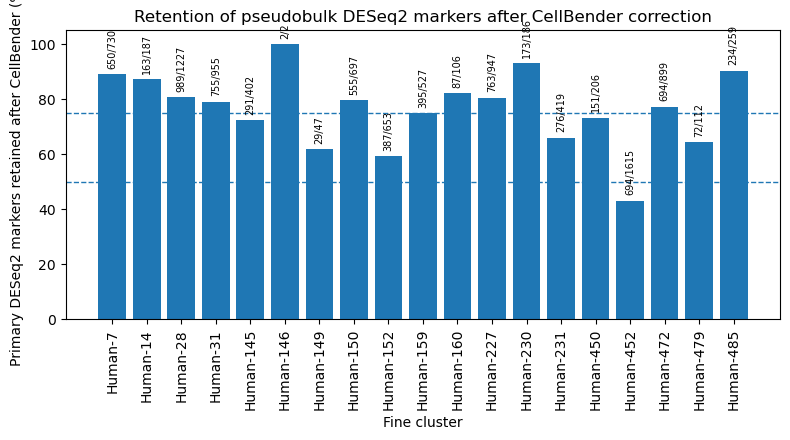

Saved figure: /home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_marker_retention_fraction_by_cluster.pdf
Saved figure: /home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_marker_retention_fraction_by_cluster.png


In [43]:
import pandas as pd
import matplotlib.pyplot as plt

summary_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_marker_retention_before_after_CellBender_by_cluster.csv"

output_fig_pdf = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_marker_retention_fraction_by_cluster.pdf"
output_fig_png = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_marker_retention_fraction_by_cluster.png"

summary = pd.read_csv(summary_file)

# Make sure numeric columns are numeric
numeric_cols = [
    "primary_DESeq2_markers",
    "CellBender_DESeq2_markers",
    "shared_DESeq2_markers",
    "primary_retention_fraction",
    "jaccard_index",
    "primary_only",
    "CellBender_only",
]

for c in numeric_cols:
    if c in summary.columns:
        summary[c] = pd.to_numeric(summary[c], errors="coerce")

# Sort clusters by numeric part
def cluster_sort_key(x):
    try:
        return int(str(x).split("-")[-1])
    except Exception:
        return 999999

summary = (
    summary
    .assign(cluster_order=summary["cluster"].map(cluster_sort_key))
    .sort_values("cluster_order")
    .reset_index(drop=True)
)

# Recalculate retention explicitly, in case stored values were problematic
summary["retention_pct"] = (
    summary["shared_DESeq2_markers"]
    / summary["primary_DESeq2_markers"]
    * 100
)

print(summary[[
    "cluster",
    "primary_DESeq2_markers",
    "CellBender_DESeq2_markers",
    "shared_DESeq2_markers",
    "retention_pct",
    "primary_only",
    "CellBender_only"
]].to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(max(8, summary.shape[0] * 0.4), 4.5))

ax.bar(
    summary["cluster"],
    summary["retention_pct"]
)

ax.set_ylabel("Primary DESeq2 markers retained after CellBender (%)")
ax.set_xlabel("Fine cluster")
ax.set_ylim(0, 105)
ax.set_title("Retention of pseudobulk DESeq2 markers after CellBender correction")

ax.axhline(75, linestyle="--", linewidth=1)
ax.axhline(50, linestyle="--", linewidth=1)

plt.xticks(rotation=90)

# Optional: annotate numerator/denominator for clarity
for i, row in summary.iterrows():
    ax.text(
        i,
        row["retention_pct"] + 2,
        f'{int(row["shared_DESeq2_markers"])}/{int(row["primary_DESeq2_markers"])}',
        ha="center",
        va="bottom",
        fontsize=7,
        rotation=90
    )

plt.tight_layout()
plt.savefig(output_fig_pdf, bbox_inches="tight")
plt.savefig(output_fig_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure: {output_fig_pdf}")
print(f"Saved figure: {output_fig_png}")

  cluster  primary_DESeq2_markers  CellBender_DESeq2_markers  shared_DESeq2_markers  retention_pct  low_marker_count
  Human-7                     730                        706                    650      89.041096             False
 Human-14                     187                        192                    163      87.165775             False
 Human-28                    1227                       1142                    989      80.603097             False
 Human-31                     955                        772                    755      79.057592             False
Human-145                     402                        320                    291      72.388060             False
Human-146                       2                          3                      2     100.000000              True
Human-149                      47                         30                     29      61.702128             False
Human-150                     697                        590    

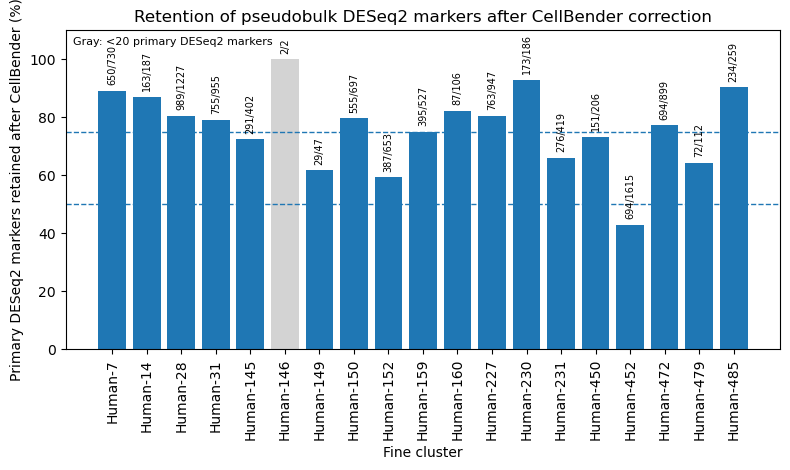

Saved figure: /home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_marker_retention_fraction_by_cluster.pdf
Saved figure: /home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_marker_retention_fraction_by_cluster.png


In [41]:
import pandas as pd
import matplotlib.pyplot as plt

summary_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_marker_retention_before_after_CellBender_by_cluster.csv"

output_fig_pdf = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_marker_retention_fraction_by_cluster.pdf"
output_fig_png = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_marker_retention_fraction_by_cluster.png"

summary = pd.read_csv(summary_file)

numeric_cols = [
    "primary_DESeq2_markers",
    "CellBender_DESeq2_markers",
    "shared_DESeq2_markers",
    "primary_only",
    "CellBender_only",
]

for c in numeric_cols:
    summary[c] = pd.to_numeric(summary[c], errors="coerce")

def cluster_sort_key(x):
    try:
        return int(str(x).split("-")[-1])
    except Exception:
        return 999999

summary = (
    summary
    .assign(cluster_order=summary["cluster"].map(cluster_sort_key))
    .sort_values("cluster_order")
    .reset_index(drop=True)
)

summary["retention_pct"] = (
    summary["shared_DESeq2_markers"]
    / summary["primary_DESeq2_markers"]
    * 100
)

# Mark clusters with very few primary DESeq2 markers
min_marker_threshold = 20
summary["low_marker_count"] = summary["primary_DESeq2_markers"] < min_marker_threshold

print(summary[[
    "cluster",
    "primary_DESeq2_markers",
    "CellBender_DESeq2_markers",
    "shared_DESeq2_markers",
    "retention_pct",
    "low_marker_count"
]].to_string(index=False))

fig, ax = plt.subplots(figsize=(max(8, summary.shape[0] * 0.4), 4.8))

x = range(summary.shape[0])

# Use default colors, but gray low-marker clusters explicitly
colors = ["lightgray" if v else "C0" for v in summary["low_marker_count"]]

ax.bar(
    x,
    summary["retention_pct"],
    color=colors
)

ax.set_ylabel("Primary DESeq2 markers retained after CellBender (%)")
ax.set_xlabel("Fine cluster")
ax.set_ylim(0, 110)
ax.set_title("Retention of pseudobulk DESeq2 markers after CellBender correction")

ax.axhline(75, linestyle="--", linewidth=1)
ax.axhline(50, linestyle="--", linewidth=1)

ax.set_xticks(list(x))
ax.set_xticklabels(summary["cluster"], rotation=90)

# Add shared/primary labels
for i, row in summary.iterrows():
    ax.text(
        i,
        row["retention_pct"] + 2,
        f'{int(row["shared_DESeq2_markers"])}/{int(row["primary_DESeq2_markers"])}',
        ha="center",
        va="bottom",
        fontsize=7,
        rotation=90
    )

# Add a small note
ax.text(
    0.01,
    0.98,
    f"Gray: <{min_marker_threshold} primary DESeq2 markers",
    transform=ax.transAxes,
    va="top",
    fontsize=8
)

plt.tight_layout()
plt.savefig(output_fig_pdf, bbox_inches="tight")
plt.savefig(output_fig_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure: {output_fig_pdf}")
print(f"Saved figure: {output_fig_png}")

### sanity check to double-check

In [31]:
import numpy as np
from scipy.sparse import issparse

# -----------------------------
# 1. Check that CellBender layer is integer-like raw counts
# -----------------------------
X_cb = h19.layers["cellbender_counts"]

if issparse(X_cb):
    data = X_cb.data
else:
    data = X_cb.ravel()

print("CellBender layer min:", data.min())
print("CellBender layer max:", data.max())
print("CellBender layer integer-like:", np.allclose(data, np.round(data), atol=1e-6))


# -----------------------------
# 2. Check that h19_cluster_ds keeps the same CellBender counts
#    for the same cells and genes
# -----------------------------
rng = np.random.default_rng(123)

cells_to_check = rng.choice(
    h19_cluster_ds.obs_names,
    size=min(1000, h19_cluster_ds.n_obs),
    replace=False
)

genes_to_check = rng.choice(
    h19_cluster_ds.var_names,
    size=min(1000, h19_cluster_ds.n_vars),
    replace=False
)

# indices in h19 and h19_cluster_ds
h19_cell_idx = h19.obs_names.get_indexer(cells_to_check)
ds_cell_idx = h19_cluster_ds.obs_names.get_indexer(cells_to_check)

h19_gene_idx = h19.var_names.get_indexer(genes_to_check)
ds_gene_idx = h19_cluster_ds.var_names.get_indexer(genes_to_check)

A = h19.layers["cellbender_counts"][h19_cell_idx][:, h19_gene_idx]
B = h19_cluster_ds.layers["cellbender_counts"][ds_cell_idx][:, ds_gene_idx]

if issparse(A):
    A = A.toarray()
if issparse(B):
    B = B.toarray()

print("Downsampled object layer matches original h19 layer:")
print(np.array_equal(A, B))
print("Max absolute difference:", np.max(np.abs(A - B)))


# -----------------------------
# 3. Check that X is normalized/log1p, not raw counts
# -----------------------------
X_norm = h19_cluster_ds.X[ds_cell_idx][:, ds_gene_idx]
X_counts = h19_cluster_ds.layers["cellbender_counts"][ds_cell_idx][:, ds_gene_idx]

if issparse(X_norm):
    X_norm = X_norm.toarray()
if issparse(X_counts):
    X_counts = X_counts.toarray()

print("X identical to CellBender raw counts?")
print(np.array_equal(X_norm, X_counts))

print("X integer-like?")
print(np.allclose(X_norm, np.round(X_norm), atol=1e-6))

print("Counts integer-like?")
print(np.allclose(X_counts, np.round(X_counts), atol=1e-6))

CellBender layer min: 1
CellBender layer max: 2969
CellBender layer integer-like: True
Downsampled object layer matches original h19 layer:
True
Max absolute difference: 0
X identical to CellBender raw counts?
False
X integer-like?
False
Counts integer-like?
True


In [32]:
X_test, genes_test = _get_counts_matrix(h19_cluster_ds, layer_key="cellbender_counts")

print("DESeq2 input shape:", X_test.shape)
print("DESeq2 input integer-like:", np.allclose(X_test[:1000, :1000], np.round(X_test[:1000, :1000])))
print("DESeq2 input max:", X_test[:1000, :1000].max())
print("Genes identical to var_names:", np.array_equal(np.asarray(genes_test), np.asarray(h19_cluster_ds.var_names)))

DESeq2 input shape: (19142, 36601)
DESeq2 input integer-like: True
DESeq2 input max: 190
Genes identical to var_names: True
